In [2]:
import pickle
import os
import copy
import matplotlib.pyplot as plt
import numpy as np
import paper_style  # apply the style automatically
import gc
import psutil
import yaml
import sys
import torch
import io
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




# Input Config

In [3]:
# time_analysis_only_root = '/home/evrond/analysis_data/time_and_freq_analysis'
# task_and_cols_only_root =  '/home/evrond/analysis_data/final_analysis/task_and_collision_anslysis'
all_analysis =  '/home/evrond/analysis_data/final_analysis/0709/500ts/time_task_collision'

disk_analysis = '/home/evrond/analysis_data/final_analysis/disk'
root_path = all_analysis # '/home/evrond/mr_mpc_logs/BATCH_2025-09-08_17:33:55_job6527715'
# root_path = task_and_cols_only_root   # '/home/evrond/analysis_data/final_analysis/task_and_collision_anslysis'
# root_path = '/home/evrond/mr_mpc_logs/BATCH_2025-09-08_16:39:28_job6525238/2025-09-08_16:39:28_R_ur5e_N4_AO_Tfollow_s3_l1'
time_analysis = True #True
task_analysis = True
split_reach_task = True # split reach task into hard and easy groups
# # Inputs:

# root_paths_time_analysis = [] #[tmp_O_w5000_cov05_trust3, verified_01_09] # batch_01_09_follow_reach_new_bugfix_in_logging_cols # change this to the root path of the simulations you want to check
# root_paths_task_analysis = []
# if task_analysis:
#     root_paths_task_analysis.append(task_and_cols_root, both_analysis_root)
# if time_analysis:
#     root_paths_time_analysis.append(time_analysis_root,both_analysis_root)
# root_paths_time_analysis = both_analysis_root
root_paths_task_analysis = [all_analysis]
root_paths_time_analysis = [all_analysis]
verbose = False
n_max = 1000 # max number of simulations to load (to prevent ram errors load at most 1000)
BATCH_SIZE = 50 # Batch size  for sim files loading. Adjust this based on your RAM - smaller = less memory usage 
exclude_substrings = [
    "SC/N800_H40_cov005"
 # 'O-/N400_H40_cov005_w100000_DEPRECATED_BEFORE_NEW_IMPLEMENTATION'
 ] # 'Tfollow','Tbin'] # Exclude old version reach and follow simulations
# load_only = {
#     'task_type': ['bin','reach','follow'], # ['reach', 'follow', 'bin']
#     'alg': ['O','O-','SC','SD','CC'] # ['SC'] # ['SC'], # ['O','O-','SC','SD','CC']
#     }
load_only = {}
tuning_load_only = {} # empty means load all










# Utils

In [4]:
# Helper and classes to manage sims
def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024
    
def save_plot_to_pdf(file_path):
    plt.savefig(f'{file_path}.pdf')

def find_task_statman_name(stats):
    for statman_name in stats.keys():
        if 'agent' not in statman_name:
            return statman_name
    return None

def find_agent_statman_names(stats):
    agent_statman_names = []
    for statman_name in stats.keys():
        if 'agent' in statman_name:
            agent_statman_names.append(statman_name)
    return agent_statman_names

def get_stat_from_statman(statman, stat_name, keys='all'):
    stat = statman[stat_name]
    if keys == 'all':
        return stat
    
    stat_filtered = []
    for stat_keys,stat_vals in stat.items():
        filtered_entry_keys = {}
        for key in keys:
            if key in stat_keys:
                filtered_entry_keys[key] = stat_vals[key]
                filtered_entry_vals = stat_vals
                stat_filtered.append((filtered_entry_keys,filtered_entry_vals))
    return stat_filtered
    
    
def split_task_to_k_v(stat):
    k = []
    v = []
    for item in stat:
        k.append(item[0])
        v.append(item[1])
    return k, v

def parse_task_by_dirname(root_path, simulation_dir):
    if 'name_format_1' in root_path:
        task_string = simulation_dir.split('_')[-1]
        task_type = task_string[:-1]
        task_seed = 0
        task_level = task_string[-1]
    
    # elif 'name_format_2' in root_path:
    else:
        task_string = simulation_dir.split('T')[-1]
        task_string_splitted = task_string.split('_')
        task_type = task_string_splitted[0]
        assert len(task_string_splitted) == 3, f'task string {task_string} is not in the correct format'
        assert task_string_splitted[1][0] == 's' and task_string_splitted[2][0] == 'l', f'task string {task_string} is not in the correct format'
        task_seed = int(task_string_splitted[1][1:])
        task_level = int(task_string_splitted[2][1:])
    # else:
    #     raise ValueError(f'root path {root_path} not supported')
    assert task_type in ['bin', 'reach','manual','follow'], f'task type {task_type} not supported'
    return task_type, task_seed, task_level

    

def parse_sim_info_by_dirname(root_path, simulation_dir):
    

    splitted_string = simulation_dir.split('_')
    timestamp = splitted_string[0] + '_' + splitted_string[1]
    robot_name = splitted_string[3]
    n_arms = int(splitted_string[4][1:])
    alg = splitted_string[5][1:]
    task_parsed = parse_task_by_dirname(root_path, simulation_dir)
    task_type, task_seed, task_level = task_parsed


    
    return {'timestamp':timestamp, 
    'robot_name':robot_name, 
    'n_arms':n_arms, 
    'alg':alg, 
    'task_type':task_type, 
    'task_seed':task_seed, 
    'task_level':task_level
    }


class SimStats:
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        self.task_stats_parsed = []
        self.meta_data = meta_data
        self.sim_stats = sim_stats
        self.task_stats = sim_stats['task_stats']
        agents_statman_names = [x for x in sim_stats.keys() if 'agent' in x]
        agents_statman_names.sort(key=lambda x: int(x.split('_')[-1])) # sort by agent index
        self.agent_stats = []
        for statman_name in agents_statman_names:
            self.agent_stats.append(sim_stats[statman_name])
        
        
        self.parsed = self.parse()
        if len(sort_by) > 0:
            self.parsed = sorted(self.parsed, key=lambda x: x[sort_by[0]])

        self._make_agents_dfs()
        


    def _make_agents_dfs(self):
        agents_tmp_lists = []
        for agent_idx in range(self.get_n_agents()):
            columns = []
            

            # find all columns
            for stat_name in self.agent_stats[agent_idx].keys():
                if stat_name not in columns:
                    columns.append(stat_name)    
                stat = self.agent_stats[agent_idx][stat_name]
                for kv in stat:
                    for k in kv[0]:
                        if k not in columns:
                            columns.append(k)

            # fill in the data  
            rows = []
            colname_to_index = {col:i for i, col in enumerate(columns)}
            for stat_name in self.agent_stats[agent_idx].keys():
                stat = self.agent_stats[agent_idx][stat_name]
                stat_col_idx = colname_to_index[stat_name]
                for kv in stat: # for each row in the stat
                    new_data_row = [None for _ in range(len(columns))]
                    val = kv[1]
                    if stat_name == 'env_cols':
                        try:
                            val = val.cpu().item()
                        except:
                            try:
                                val = val.item()
                            except:
                                val = val
                    new_data_row[stat_col_idx] = val
                    for k in kv[0]:
                        new_data_row[colname_to_index[k]] = kv[0][k]
                    rows.append(new_data_row)
            
            # save the agents raw data for df
            agents_tmp_lists.append((columns, rows))
        
        # make dfs
        self._agents_dfs = []
        for agent_idx in range(self.get_n_agents()):
            agent_df =  pd.DataFrame(columns=agents_tmp_lists[agent_idx][0], data=agents_tmp_lists[agent_idx][1])
            self._agents_dfs.append(agent_df)
            
                    

    def get_agents_dfs(self):
        return self._agents_dfs
        
    def parse(self):
        parsed = []
        # print(f'parsing sim')
        for statman_name in self.sim_stats.keys():
            # print(f'\nparsing stat-manager: {statman_name}...')
            for stat_name in self.sim_stats[statman_name].keys():
                # print(f'    parsing stat: {stat_name}...')
                stat_vals = self.sim_stats[statman_name][stat_name]
                # stat_entries = []
                for stat_kv in stat_vals:        
                    # stat entry (unique key)
                    s_entry = {}
                    s_entry[f'{statman_name}_{stat_name}'] = stat_kv[1]
                    for k_key, v_key in stat_kv[0].items():
                        s_entry[k_key] = v_key
                    # stat_entries.append(s_entry)
                    parsed.append(s_entry)
                # stat_entries.append(s_entry)
        # print(f'parsing finished, parsed {len(parsed)} entries')
        return parsed
        
    def __repr__(self):
        out = '\n'
        for k,v in self.meta_data.items():
            out += f'{k}: {v}\n'
        return out
        
    def check_necessary_key(self, entry:dict,key:str):
        for k_entry in entry.keys():
            if key in k_entry:
                return True # found the key substring

        return False
    
    def set_planning_times(self, agents_planning_times, agents_clocktimes, agents_physics_times, agents_n_steps):
        # print(f'agents_planning_times: {agents_planning_times}')
        # print(f'agents_clocktimes: {agents_clocktimes}')
        # print(f'agents_physics_times: {agents_physics_times}')
        # print(f'agents_n_steps: {agents_n_steps}')
        
        self.agents_planning_times = agents_planning_times # total time spent in planning
        self.agents_clocktimes = agents_clocktimes # total wall time (system time) simualation + planning (should be ~same for all agents in the same simulation)
        self.agents_physics_times = agents_physics_times # total physics time simulation (should be same for all agents in the same simulation)
        self.agents_n_steps = agents_n_steps # total number of steps (should be same for all agents in the same simulation)
        self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        # self.planning_time_per_step =  [agents_planning_times[i] / agents_n_steps[i] for i in range(len(agents_planning_times))]
        n_agents = len(agents_planning_times)
        self.mean_agent_planning_time = sum(agents_planning_times) / n_agents 
        self.mean_planning_time_per_step = sum(self.planning_time_per_step) / n_agents # normalized mean planning time per step, so we can compare between simulations in different number of steps
        self.total_clocktime = max(agents_clocktimes) # (should be similar)
        self.total_physics_time = max(agents_physics_times) #  should be the same for all agents in the same simulation
    
    def get_n_agents(self):
        centralized = self.is_centralized()
        n_agents = 1 if centralized else self.meta_data['n_arms']
        return n_agents
    
    def is_centralized(self):
        alg = self.meta_data['alg']
        centralized = alg not in ['O', 'O-', 'SD']
        return centralized
    
    
    
    def get_n_arms(self):
        return self.meta_data['n_arms']

    def make_task_df(self):
        
        columns = []
        rows = []
        reverse_col_name_to_index = {}

        # find all columns
        for entry in self.task_stats_parsed:
            for k,v in entry.items():
                if k not in columns:
                    columns.append(k)
                    reverse_col_name_to_index[k] = len(columns) - 1

        # fill in the data
        for entry in self.task_stats_parsed:
            new_data_row = [None for _ in range(len(columns))]
            for k,v in entry.items():
                new_data_row[reverse_col_name_to_index[k]] = v
            rows.append(new_data_row)

        # rows.append(entry)
        task_df = pd.DataFrame(rows, columns=columns)
        
        # remove duplicates
        task_df = task_df.drop_duplicates()
        
        return task_df
    
    
    
class ReachSimStats(SimStats):
    
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        tmp_reached_by_t = [0 for _ in range(self.n_arms)]
        tmp_changed_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        # print(f'len(sorted_parsed): {len(sorted_parsed)}')
        for entry in sorted_parsed:
            
            if not (self.check_necessary_key(entry,'task_stats_arm_reached') or self.check_necessary_key(entry,'task_stats_arm_changed')):
                continue # not a task related entry
            
            arm_stats_entry = {}
            # entry_keys = entry.keys()

            

            for k in entry.keys():
                if k == 'task_stats_arm_reached':
                    for arm_idx in entry[k]:
                        tmp_reached_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_changed':
                    for arm_idx in entry[k]:
                        tmp_changed_by_t[arm_idx] += 1
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_reached'] = tmp_reached_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_changed'] = tmp_changed_by_t[arm_idx]
        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class BinSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()

    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        
        tmp_picks_by_t = [0 for _ in range(self.n_arms)]
        tmp_drops_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not (self.check_necessary_key(entry,'task_stats_arm_picks') or self.check_necessary_key(entry,'task_stats_arm_drops') or self.check_necessary_key(entry,'task_stats_arm_err')):
                continue # not a task related entry
                
            for k in entry.keys():

                if k == 'task_stats_arm_picks':
                    for arm_idx in entry[k]:
                        tmp_picks_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_drops':
                    for arm_idx in entry[k]:
                        tmp_drops_by_t[arm_idx] += 1


            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_picks'] = tmp_picks_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_drops'] = tmp_drops_by_t[arm_idx]
                        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
    
class FollowSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()
        
    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        self.task_stats_parsed = []
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not self.check_necessary_key(entry,'task_stats_arm_err'):
                continue # not a task related entry
                
            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_err'] = entry[f'task_stats_arm_err'][arm_idx]
                
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed


    
def should_load_sim(sim_dir_path,load_settings={},tuning_settings={}):
    root, sim_dir_name = os.path.split(sim_dir_path)
    sim_info = parse_sim_info_by_dirname(root, sim_dir_name)

    
    
    
    for set_name in load_settings:
        if sim_info[set_name] not in load_settings[set_name]:
            return False
    return True

        
 
    
    return True

def find_sims_in_tree(root_path,exclude_substrings=[]):
    sim_paths = []
    for root, dirs, files in os.walk(root_path):
        for file in files:
            if file.endswith('.pkl'):
                full_path = os.path.join(root, file)
                exclude = False
                for exclude_substring in exclude_substrings:
                    print(f'Checking if {exclude_substring} is in {full_path}')
                    if exclude_substring in full_path:
                        print(f'Found {exclude_substring} in {full_path}')
                        exclude = True
                        break
                if not exclude:
                    sim_paths.append(full_path)
    return sim_paths
    
 

def remap_alg_name_mppi(meta_data: dict):
    
    return meta_data['alg'] + f'({meta_data["particle_cfg"]["mppi"]["num_particles"]}, {meta_data["particle_cfg"]["mppi"]["n_iters"]})'    


def find_valid_sims_for_loading(root_paths, verbose=True):
    # Find all simulation directories
    simulation_dirs = []
    for root_tree in root_paths:
        simulation_dirs += find_sims_in_tree(root_tree, exclude_substrings)

    n_sims = len(simulation_dirs)
    n_load = min(n_sims, n_max)

    # Filter and collect valid simulations (but don't load the data yet!)
    valid_sim_pkl_paths = []
    valid_sim_dir_paths = []
    valid_sim_names = []

    if verbose:
        print(f'Filtering {n_load} simulations...')
    loaded = 0

    for i, sim_pkl_path in enumerate(simulation_dirs):
        if loaded >= n_max:
            break
        if verbose:
            print(f'    Checking Simulation {i+1} out of {n_load} (loaded = {loaded})')
        
        try:    
            sim_dir_path, pkl_name = os.path.split(sim_pkl_path)
            sim_name = os.path.splitext(sim_dir_path)[1]
            
            if not should_load_sim(sim_dir_path, load_only, tuning_load_only):
                continue
                
            if os.path.exists(sim_pkl_path):
                valid_sim_pkl_paths.append(sim_pkl_path)
                valid_sim_dir_paths.append(sim_dir_path)
                valid_sim_names.append(sim_name)
                loaded += 1
                if verbose:
                    print(f'    Valid Simulation dir: {sim_dir_path}')
        except:
            if verbose:
                print(f'Error checking simulation {i}: {sim_pkl_path}')
            continue

    if verbose:
        print(f'\nFound {len(valid_sim_pkl_paths)} valid simulations to process')


    return valid_sim_dir_paths, valid_sim_names, valid_sim_pkl_paths


class BinSimStats(SimStats):
    def __init__(self, meta_data, sim_stats, sort_by=['w_step']):
        super().__init__(meta_data, sim_stats, sort_by)
        self.parsed_task_stats = self.parse_task_stats()
        self.task_df = self.make_task_df()

    def parse_task_stats(self):
        self.n_arms = self.meta_data['n_arms']
        
        tmp_picks_by_t = [0 for _ in range(self.n_arms)]
        tmp_drops_by_t = [0 for _ in range(self.n_arms)]
        
        sorted_parsed = sorted(self.parsed, key=lambda x: x['w_step'])
        for entry in sorted_parsed:
            arm_stats_entry = {}
            
            if not (self.check_necessary_key(entry,'task_stats_arm_picks') or self.check_necessary_key(entry,'task_stats_arm_drops') or self.check_necessary_key(entry,'task_stats_arm_err')):
                continue # not a task related entry
                
            for k in entry.keys():

                if k == 'task_stats_arm_picks':
                    for arm_idx in entry[k]:
                        tmp_picks_by_t[arm_idx] += 1
                
                if k == 'task_stats_arm_drops':
                    for arm_idx in entry[k]:
                        tmp_drops_by_t[arm_idx] += 1


            arm_stats_entry['w_step'] = entry['w_step']
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_picks'] = tmp_picks_by_t[arm_idx]
            
            for arm_idx in range(self.n_arms):
                arm_stats_entry[f'arm_{arm_idx}_total_drops'] = tmp_drops_by_t[arm_idx]
                        
            self.task_stats_parsed.append(arm_stats_entry)
        return self.task_stats_parsed
def safe_load_pickle(pkl_path):
    """Safely load pickle file with CUDA->CPU mapping"""
    # Store original torch.load
    original_torch_load = torch.load
    
    # Create a patched version that always maps to CPU
    def patched_torch_load(f, map_location=None, weights_only=False, **kwargs):
        # Remove weights_only from kwargs if it exists to avoid duplicate argument
        if 'weights_only' in kwargs:
            del kwargs['weights_only']
        return original_torch_load(f, map_location=torch.device('cpu'), weights_only=False, **kwargs)
    
    try:
        # Patch torch.load globally
        torch.load = patched_torch_load
        
        # Try loading with regular pickle first
        with open(pkl_path, 'rb') as f:
            stats = pickle.load(f)
        return stats
        
    except Exception as e:
        # If pickle fails, try torch.load directly
        try:
            with open(pkl_path, 'rb') as f:
                stats = original_torch_load(f, map_location=torch.device('cpu'), weights_only=False)
            return stats
        except Exception as torch_e:
            print(f'Failed to load {pkl_path}: {e} -> {torch_e}')
            return None
    finally:
        # Always restore original torch.load
        torch.load = original_torch_load

def load_and_process_sim_files(sim_pkl_paths, sim_dir_paths, batch_size=50):
    """Process simulations in batches to manage memory efficiently"""
    reach_sims = []
    bin_sims = []
    follow_sims = []
    disk_sims = []

    for i in range(0, len(sim_pkl_paths), batch_size):
        batch_paths = sim_pkl_paths[i:i+batch_size]
        batch_dirs = sim_dir_paths[i:i+batch_size]
        
        print(f'Processing batch {i//batch_size + 1}: simulations {i+1}-{min(i+batch_size, len(sim_pkl_paths))}')
        print(f'Memory usage before batch: {get_memory_usage():.1f} MB')
        
        # Load batch of raw data
        batch_stats = []
        for j, pkl_path in enumerate(batch_paths):
            if os.path.exists(pkl_path):
                stats = safe_load_pickle(pkl_path)
                batch_stats.append(stats)
            else:
                batch_stats.append(None)
        
        # Process batch into analyzer objects
        for j, (stats, dir_path) in enumerate(zip(batch_stats, batch_dirs)):
            if stats is None:
                continue
                
            sim_parent_dir, sim_name_parsed = os.path.split(dir_path)
            meta_data = parse_sim_info_by_dirname(sim_parent_dir, sim_name_parsed)
            mppi = meta_data['alg'] in ['O','O-','SC','SD']
            
            try:

                if mppi:
                    with open(os.path.join(dir_path,'particle_cfg.yml'), 'r') as f:
                        
                        particle_cfg = yaml.load(f, Loader=yaml.FullLoader)
                        meta_data['particle_cfg'] = particle_cfg
                        meta_data['alg'] = remap_alg_name_mppi(meta_data)
                    
                else:
                    if '/IK' in dir_path:
                        if '/IK500' in dir_path:
                            meta_data['alg'] += '(500)'
                        elif '/IK1000' in dir_path:
                            meta_data['alg'] += '(1000)'
            except Exception as e:
                print(f'Error processing simulation {dir_path}: {e}')
                print(f'Meta data: {meta_data}')
                print('-'*100)
                continue
            
            try:
                if meta_data['task_type'] == 'reach':
                    reach_sims.append(ReachSimStats(meta_data, stats))
                elif meta_data['task_type'] == 'bin':
                    bin_sims.append(BinSimStats(meta_data, stats))
                elif meta_data['task_type'] == 'follow':
                    follow_sims.append(FollowSimStats(meta_data, stats))
                elif meta_data['task_type'] == 'disk':
                    disk_sims.append(FollowSimStats(meta_data, stats)) # same parsing
            except Exception as e:
                print(f'Error processing simulation {dir_path}: {e}')
                print(f'Meta data: {meta_data}')
                print('-'*100)
                continue
        
        # CRITICAL: Free batch memory immediately after processing
        del batch_stats
        gc.collect()
        
        print(f'Memory usage after batch: {get_memory_usage():.1f} MB')
        print(f'Processed so far: {len(reach_sims)} reach, {len(bin_sims)} bin, {len(follow_sims)} follow')
        print('-' * 50)
    
    return reach_sims, bin_sims, follow_sims, disk_sims

def print_parsing_summary(successfull_parsing, unsuccessfull_parsing):
    print(f'parsing summary:')
    print(f'successfull_parsing: {len(successfull_parsing)}')
    print(f'unsuccessfull_parsing: {len(unsuccessfull_parsing)}')
    print(f'to view errors, see unsuccessfull_parsing[i][1] for error message')


def make_df_times(all_sims):
    successfull_parsing = []
    unsuccessfull_parsing = []

    for sim_idx, sim in enumerate(all_sims):
        try:    
            # print(f'\n\n\nsim_idx: {sim_idx}, alg: {sim.meta_data["alg"]}\n\n\n')
            n_arms = sim.meta_data['n_arms']
            n_agents = sim.get_n_agents()
            agent_to_final_planning_time = [0] * n_agents
            # agent_entries = [[] for _ in range(n_agents)]
            min_wstep_entry, min_wstep = [{} for _ in range(n_agents)], [100000] * n_agents
            max_wstep_entry, max_wstep  = [{} for _ in range(n_agents)], [-1] * n_agents
            for i in range(len(sim.parsed)):
                data_entry = sim.parsed[i]
                for a_idx in range(n_agents):
                    if 'tsys' in data_entry:
                        pass
                        # print(f'debug:entry {i} a{a_idx} {data_entry["tsys"]}')
                    a_key_total_planning_time = f'agent_{a_idx}_total_planning_time'
                    if a_key_total_planning_time in data_entry:
                        if data_entry['w_step'] < min_wstep[a_idx]:
                            min_wstep_entry[a_idx] = copy.deepcopy(data_entry)
                            min_wstep[a_idx] = data_entry['w_step']
                        if data_entry['w_step'] > max_wstep[a_idx]:
                            max_wstep_entry[a_idx] = copy.deepcopy(data_entry)
                            max_wstep[a_idx] = data_entry['w_step']

            agents_planning_times = [0] * n_agents
            agents_clocktimes = [0] * n_agents
            agents_physics_times = [0] * n_agents
            agents_n_steps = [0] * n_agents
            
            for a_idx in range(n_agents): 
                if max_wstep[a_idx] <= 0:
                    raise Exception(f'agent {a_idx} has no planning time')
            
            
            #print(f'all_agents_have_planning_time: {all_agents_have_planning_time}')
            for a_idx in range(n_agents):
                a_key_total_planning_time = f'agent_{a_idx}_total_planning_time'   
                agents_planning_times[a_idx] = max_wstep_entry[a_idx][a_key_total_planning_time]
                agents_n_steps[a_idx] = max_wstep[a_idx] # if not working try w_step
                agents_clocktimes[a_idx] = max_wstep_entry[a_idx]['tsys'] - min_wstep_entry[a_idx]['tsys']
                agents_physics_times[a_idx] = max_wstep_entry[a_idx]['tphysics'] - min_wstep_entry[a_idx]['tphysics']
            all_sims[sim_idx].set_planning_times(agents_planning_times, agents_clocktimes, agents_physics_times, agents_n_steps)
        
            successfull_parsing.append(sim)
        except Exception as e:
            unsuccessfull_parsing.append((sim,e))
            # print('agent', a_idx, data_entry[a_key_total_planning_time])

    df_cols = ['alg', 'task_type', 'task_level', 'n_arms', 'wsteps', 'tplanning_moaw', 'ctrl_freq_moaw', 'sim_clocktime', 'sim_physics_time']
    rows = []


    for sim in successfull_parsing:
    # for sim_idx, sim in enumerate(all_sims):
        sim_df = sim.task_df
        alg = sim.meta_data['alg']
        task_type = sim.meta_data['task_type']
        task_level = sim.meta_data['task_level']
        # task_seed = sim.meta_data['task_seed']
        n_arms = sim.meta_data['n_arms']
        # print(f'sim_df.columns: {sim_df.columns}')
        w_steps = sim_df['w_step'].max()
        # tsys = sim_df['tsys'].max() - sim_df['tsys'].min() 
        # tphysics = sim_df['tphysics'].max() - sim_df['tphysics'].min()
        tplanning_moaw = sim.mean_planning_time_per_step
        ctrl_freq_moaw = 1/tplanning_moaw
        sim_clocktime = sim.total_clocktime
        sim_physics_time = sim.total_physics_time
        rows.append([alg, task_type, task_level, n_arms, w_steps, tplanning_moaw, ctrl_freq_moaw, sim_clocktime, sim_physics_time])


    df_planning_time = pd.DataFrame(rows, columns=df_cols)
    return df_planning_time




# Also add a function to show data counts for debugging
def show_algorithm_counts(df_planning_time):
    print("Algorithm counts by task type:")
    count_df = df_planning_time.groupby(['task_type', 'alg']).size().reset_index(name='count')
    print(count_df)
    
    print("\nTotal counts per algorithm:")
    print(df_planning_time['alg'].value_counts())


def plot_rrc_by_alg(overall_df):
    """Robot-Robot Collision Risk by Algorithm"""
    # Safety Analysis: Box plots by algorithm for each task
    try:
        fig, axs = plt.subplots(1, 3, figsize=(18, 5))

        # Get unique algorithms and assign colors (same as performance plots)
        algorithms = overall_df['alg'].unique()
        colors = plt.cm.tab10(np.linspace(0, 1, len(algorithms)))

        # Box plot for reach task safety by algorithm
        reach_data = overall_df[overall_df.task_type == 'reach']
        reach_alg_data = [reach_data[reach_data['alg'] == alg]['rrc_chance'] for alg in algorithms]
        bp1 = axs[0].boxplot(reach_alg_data, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp1['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axs[0].set_title('Reach Task - Robot-Robot Collision Risk by Algorithm')
        axs[0].set_xlabel('Algorithm')
        axs[0].set_ylabel('Robot-Robot Collision Chance (RRC)')
        axs[0].grid(True, alpha=0.3)
        axs[0].set_ylim(bottom=0)  # Start from 0 for better comparison

        # Box plot for bin task safety by algorithm
        bin_data = overall_df[overall_df.task_type == 'bin']
        bin_alg_data = [bin_data[bin_data['alg'] == alg]['rrc_chance'] for alg in algorithms]
        bp2 = axs[1].boxplot(bin_alg_data, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp2['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axs[1].set_title('Bin Task - Robot-Robot Collision Risk by Algorithm')
        axs[1].set_xlabel('Algorithm')
        axs[1].set_ylabel('Robot-Robot Collision Chance (RRC)')
        axs[1].grid(True, alpha=0.3)
        axs[1].set_ylim(bottom=0)

        # Box plot for follow task safety by algorithm
        follow_data = overall_df[overall_df.task_type == 'follow']
        follow_alg_data = [follow_data[follow_data['alg'] == alg]['rrc_chance'] for alg in algorithms]
        bp3 = axs[2].boxplot(follow_alg_data, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp3['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axs[2].set_title('Follow Task - Robot-Robot Collision Risk by Algorithm')
        axs[2].set_xlabel('Algorithm')
        axs[2].set_ylabel('Robot-Robot Collision Chance (RRC)')
        axs[2].grid(True, alpha=0.3)
        axs[2].set_ylim(bottom=0)

        plt.tight_layout()
        plt.show()
        
        print("Note: Lower values indicate better safety (fewer collisions)")
    except Exception as e:
        print(f'Error creating RRC safety plot: {e}')
        pass

def bin_task_sanity_check(df_bin):
    # sanity check for bin - verifying corellation beteen n picked and n placed (picked should be <= placed)
    df_bin_sanity = df_bin.copy()
    # df_bin.plot()
    # df_bin = # df_bin[['picked_total','placed_total','alg','task_level']]
    y = df_bin_sanity['picked_total'].values
    x = df_bin_sanity['placed_total'].values
    plt.scatter(x,y)
    plt.xlabel('placed_total')
    plt.ylabel('picked_total')
    plt.title('bin task')
    plt.show()


def print_col_chance_by_alg_summary(overall_df):
    gb_alg = overall_df.groupby(['alg'])
    alg_col_sims = {} 
    for alg, df_alg in gb_alg:
        alg_col_sims[alg] = [0,len(df_alg)]
        for sim_id in df_alg['sim_id']:
            row = overall_df.loc[overall_df['sim_id'] == sim_id]
            if (row['safety_score_rrc'].values[0] < 1) or (row['safety_score_rec'].values[0] < 1):
                alg_col_sims[alg][0] += 1
    for alg, col_sims in alg_col_sims.items():
        col_chance = col_sims[0] / col_sims[1]
        print(f"{alg}: n_sims: {col_sims[1]}, n_col_sims: {col_sims[0]}, col_chance: {col_chance}")

# Robot-Environment Collision Analysis: Box plots by algorithm for each task
def plot_rec_by_alg(overall_df):
    try:
        fig, axs = plt.subplots(1, 3, figsize=(18, 5))

        # Get unique algorithms and assign colors (same as performance plots)
        algorithms = overall_df['alg'].unique()
        colors = plt.cm.tab10(np.linspace(0, 1, len(algorithms)))

        # Box plot for reach task environment collision by algorithm
        reach_data = overall_df[overall_df.task_type == 'reach']
        reach_alg_data = [reach_data[reach_data['alg'] == alg]['rre_chance'] for alg in algorithms]
        bp1 = axs[0].boxplot(reach_alg_data, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp1['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axs[0].set_title('Reach Task - Robot-Environment Collision Risk by Algorithm')
        axs[0].set_xlabel('Algorithm')
        axs[0].set_ylabel('Robot-Environment Collision Chance (RRE)')
        axs[0].grid(True, alpha=0.3)
        axs[0].set_ylim(bottom=0)

        # Box plot for bin task environment collision by algorithm
        bin_data = overall_df[overall_df.task_type == 'bin']
        bin_alg_data = [bin_data[bin_data['alg'] == alg]['rre_chance'] for alg in algorithms]
        bp2 = axs[1].boxplot(bin_alg_data, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp2['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axs[1].set_title('Bin Task - Robot-Environment Collision Risk by Algorithm')
        axs[1].set_xlabel('Algorithm')
        axs[1].set_ylabel('Robot-Environment Collision Chance (RRE)')
        axs[1].grid(True, alpha=0.3)
        axs[1].set_ylim(bottom=0)

        # Box plot for follow task environment collision by algorithm
        follow_data = overall_df[overall_df.task_type == 'follow']
        follow_alg_data = [follow_data[follow_data['alg'] == alg]['rre_chance'] for alg in algorithms]
        bp3 = axs[2].boxplot(follow_alg_data, labels=algorithms, patch_artist=True)
        for patch, color in zip(bp3['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axs[2].set_title('Follow Task - Robot-Environment Collision Risk by Algorithm')
        axs[2].set_xlabel('Algorithm')
        axs[2].set_ylabel('Robot-Environment Collision Chance (RRE)')
        axs[2].grid(True, alpha=0.3)
        axs[2].set_ylim(bottom=0)

        plt.tight_layout()
        plt.show()
        
        print("Note: Lower values indicate better safety (fewer environment collisions)")
    except Exception as e:
        print(f'Error creating RRE safety plot: {e}')
        pass

def alg_summary(alg_df):

    try:
        placed_mean_bin_sims = alg_df[alg_df['task_type'] == 'bin']['placed_total'].mean()
        print(f"N PLACED ITEMS MEAN - Bin simulations: (all arms & sims): {placed_mean_bin_sims:.2f} (n={len(alg_df[alg_df['task_type'] == 'bin'])})")  
    except Exception as e:
        placed_mean_bin_sims = None
    try:
        reached_mean_reach_sims = alg_df[alg_df['task_type'] == 'reach']['reached_total'].mean()
        print(f"N REACHED GOALS MEAN- Reach simulations: (all arms & sims): {reached_mean_reach_sims:.2f} (n={len(alg_df[alg_df['task_type'] == 'reach'])})")
    except Exception as e:
        # reached_mean_reach_sims = None
        pass
    try:
        p_err_mean_follow_sims = alg_df[alg_df['task_type'] == 'follow']['p_err_mean_arms_wsteps'].mean()
        print(f"EE POSITION ERROR MEAN - Follow simulations: (all arms, sims & steps): {p_err_mean_follow_sims:.3f} (n={len(alg_df[alg_df['task_type'] == 'follow'])})")
    except Exception as e:
        # p_err_mean_follow_sims = None
        pass
        # p_err_mean_follow_sims = None
    try:
        col_free_sim_rate = 1 - len(alg_df[(alg_df['rrc_chance'] > 0) | (alg_df['rre_chance'] > 0)]) / len(alg_df)
        print(f"COLLISION FREE SIMULATIONS RATE - All simulations - (Ncol free sims/All simulations): {col_free_sim_rate:.2f} (n={len(alg_df)})")
    except Exception as e:
        # col_free_sim_rate = None
        pass
    # col_free_sim_rate = 1 - len(alg_df[(alg_df['rrc_chance'] > 0) | (alg_df['rre_chance'] > 0)]) / len(alg_df)
    
    # print(f"N PLACED ITEMS MEAN - Bin simulations: (all arms & sims): {placed_mean_bin_sims:.2f} (n={len(alg_df[alg_df['task_type'] == 'bin'])})")
    # print(f"N REACHED GOALS MEAN- Reach simulations: (all arms & sims): {reached_mean_reach_sims:.2f} (n={len(alg_df[alg_df['task_type'] == 'reach'])})")
    # print(f"EE POSITION ERROR MEAN - Follow simulations: (all arms, sims & steps): {p_err_mean_follow_sims:.3f} (n={len(alg_df[alg_df['task_type'] == 'follow'])})")
    # print(f"COLLISION FREE SIMULATIONS RATE - All simulations - (Ncol free sims/All simulations): {col_free_sim_rate:.2f} (n={len(alg_df)})")



# Load simulations (will take a while)

Sim info

## Examples (optional)

### Example- reach simulations dfs

## 1. Planning times and control frequencies

### a. planning time per step, by alg

### definitions:
1. V_moa - the variable V, mean of all agents
2. V_moaw - the variable V, V_moa and also over all wsteps (avg per agent per step)
2. wsteps[unitless] - total number of "world" (the name of simulation environment in isaac sim) steps (total simulation steps)
3. tplanning_moan[sec] - mean of all agents planning time (avg per agent per step) - 
4. ctrl_freq_moan[hz] - mean of all agents control frequency (avg per agent per step, ctrl freq in hz. 1/tplanning_moan)
5. tphysics[sec] - total simulated physics time (wsteps x physics dt)
6. tsys[sec] - total real tiem (simualtion took), computer's system ('wall') time


In [5]:
if time_analysis:
    mem_usage_before_loading = get_memory_usage()
    valid_sim_dir_paths, valid_sim_names, valid_sim_pkl_paths = find_valid_sims_for_loading(root_paths_time_analysis, verbose=verbose) # checking input dirs
    reach_sims, bin_sims, follow_sims, disk_sims = load_and_process_sim_files(valid_sim_pkl_paths, valid_sim_dir_paths, batch_size=BATCH_SIZE)
    all_sims = bin_sims + reach_sims + follow_sims + disk_sims
    print(f'Loading finished:')
    print(f'  Reach simulations: {len(reach_sims)}')
    print(f'  Bin simulations: {len(bin_sims)}')
    print(f'  Follow simulations: {len(follow_sims)}')
    print(f'  Disk simulations: {len(disk_sims)}')  
    print(f'  Total: {len(all_sims)}')
    print(f'Mem Usage Before Loading:{mem_usage_before_loading:.1f} MB. Mem Usage After Loading: {get_memory_usage():.1f} MB')
    df_times = make_df_times(all_sims)
    
df_times if time_analysis else ''

Checking if SC/N800_H40_cov005 is in /home/evrond/analysis_data/final_analysis/0709/500ts/time_task_collision/O/N400_H40_cov05_trust3_w5000_th03_1optIter/2025-09-08_03:30:27_R_ur5e_N4_AO_Tbin_s5_l2/stats.pkl
Checking if SC/N800_H40_cov005 is in /home/evrond/analysis_data/final_analysis/0709/500ts/time_task_collision/O/N400_H40_cov05_trust3_w5000_th03_1optIter/2025-09-08_07:14:33_R_ur5e_N4_AO_Treach_s0_l10/stats.pkl
Checking if SC/N800_H40_cov005 is in /home/evrond/analysis_data/final_analysis/0709/500ts/time_task_collision/O/N400_H40_cov05_trust3_w5000_th03_1optIter/2025-09-08_05:48:45_R_ur5e_N4_AO_Treach_s2_l5/stats.pkl
Checking if SC/N800_H40_cov005 is in /home/evrond/analysis_data/final_analysis/0709/500ts/time_task_collision/O/N400_H40_cov05_trust3_w5000_th03_1optIter/2025-09-08_07:17:54_R_ur5e_N4_AO_Treach_s1_l10/stats.pkl
Checking if SC/N800_H40_cov005 is in /home/evrond/analysis_data/final_analysis/0709/500ts/time_task_collision/O/N400_H40_cov05_trust3_w5000_th03_1optIter/2025-0

,alg,task_type,task_level,n_arms,wsteps,tplanning_moaw,ctrl_freq_moaw,sim_clocktime,sim_physics_time
0,"O(400, 1)",bin,2,4,500,0.017701,56.494413,104.782081,4.15
1,"O(400, 1)",bin,4,4,500,0.018201,54.941215,103.113158,4.15
2,"O(400, 1)",bin,2,4,500,0.017220,58.070802,99.492307,4.15
3,"O(400, 1)",bin,5,4,500,0.018245,54.810053,109.439245,4.15
4,"O(400, 1)",bin,4,4,500,0.017759,56.310977,104.101144,4.15
...,...,...,...,...,...,...,...,...,...
955,CC(500),follow,2,4,500,0.233602,4.280784,158.925831,4.15
956,CC(500),follow,2,4,500,0.269375,3.712296,175.863946,4.15
957,CC(500),follow,1,4,500,0.133167,7.509378,104.757366,4.15
958,CC(500),follow,4,4,500,0.138768,7.206248,114.114919,4.15


In [6]:
def make_time_plots(df_planning_time, hz=True, mode='by_task', save=False, sort_by_box_mean=True, best_right=True, colormap=None):
    # Set plot style
    plt.rcParams.update({
        "font.size": 10,  # Smaller base font
        "figure.figsize": (16, 6),  # Wider to accommodate 4 subplots
    })

    # Create clean legend elements (shared across all modes)
    legend_elements = [
        Line2D([0], [0], color='black', lw=2, label='Median'),
        Line2D([0], [0], color='black', lw=1, ls='--', label='Mean'),
        Line2D([0], [0], marker='o', color='w', label='Outliers',
              markerfacecolor='black', markersize=6),
        Line2D([0], [0], color='black', lw=3, label='Box: 25-75%'),
        Line2D([0], [0], color='black', lw=1, label='Whiskers: 1.5×IQR'),
    ]

    # Create plot
    if mode == 'by_task':
        # Get unique task types
        task_types = df_planning_time['task_type'].unique()
        task_types = sorted(task_types)
        n_tasks = len(task_types)
        
        # Create subplots - one for each task type + overall (4 subplots total)
        fig, axes = plt.subplots(1, n_tasks + 1, figsize=(4*(n_tasks + 1), 4.5))  # +1 for overall plot
        
        # Handle case where there's only one task type
        if n_tasks == 1:
            axes = [axes[0], axes[1]]
        
        # Determine better text for overall figure
        if not hz:
            better_text = "lower=better"
            y_val_name = "Planning Time"
        else:
            better_text = "higher=better"
            y_val_name = "Control Frequency"
        
        # Add overall figure title (centered)
        fig.suptitle(f"{y_val_name} By Task (boxes are sorted by means from left to right, {better_text})", fontsize=14, y=1.02)
        
        # Calculate total N across all tasks
        total_n = 0
        task_n_values = {}
        
        # Plot each task type in its own subplot
        for i, task_type in enumerate(task_types):
            ax = axes[i]
            df_task = df_planning_time[df_planning_time['task_type'] == task_type]
            
            # Determine which column to use for sorting
            if not hz: # plot planning time/step
                y_col = 'tplanning_moaw'
                ylabel = 'Planning Time (s)'
                ascending = not best_right
            else: # plot control frequency
                y_col = 'ctrl_freq_moaw'
                ylabel = 'Control Frequency (Hz)'
                ascending = best_right
            
            # Calculate mean values for each algorithm and sort in descending order
            alg_means = df_task.groupby('alg')[y_col].mean().sort_values(ascending=ascending)
            sorted_algs = alg_means.index.tolist()
            
            # Create boxplot with sorted algorithms
            if colormap is not None:
                sns.boxplot(data=df_task, x='alg', y=y_col, hue='alg', ax=ax, showfliers=True, order=sorted_algs, palette=colormap)
            else:
                sns.boxplot(data=df_task, x='alg', y=y_col, hue='alg', ax=ax, showfliers=True, order=sorted_algs)
            
            # Add algorithm names to x-tick labels (NO N values) - INCREASED BY 30%
            ax.set_xticklabels(sorted_algs, fontsize=12)  # Increased from 9 to 12 (30% increase)
            
            # Validate that N is equal for all algorithms
            n_values = []
            for alg in sorted_algs:
                count = len(df_task[df_task['alg'] == alg])
                n_values.append(count)
            
            if len(set(n_values)) > 1:
                print(f"WARNING: Unequal sample sizes in {task_type} task: {dict(zip(sorted_algs, n_values))}")
            else:
                n_per_alg = n_values[0] if n_values else 0
                print(f"{task_type} task: N={n_per_alg} per algorithm")
                total_n += n_per_alg * len(sorted_algs)  # Add to total N
                task_n_values[task_type] = n_per_alg
            
            # Create task-specific title (without sorting info)
            task_title_map = {
                'reach': 'Reaching',
                'bin': 'Bin loading', 
                'follow': 'Following'
            }
            task_display_name = task_title_map.get(task_type, task_type.title())
            n_per_alg = n_values[0] if n_values else 0
            ax.set_title(f"{task_display_name}: N={n_per_alg} per algorithm", 
                        fontsize=12, pad=15)  # Reduced padding
            ax.set_ylabel(ylabel, fontsize=14)  # INCREASED BY 30% (from 10 to 13)
            # Remove individual x-axis labels - will be unified later
            ax.set_xlabel("", fontsize=10)  # Remove individual "Algorithm" labels
            ax.tick_params(axis='x', rotation=45, labelsize=11)  # INCREASED BY 30% (from 9 to 12)
            ax.tick_params(axis='y', labelsize=9)
            
            # Remove the duplicate legend that comes from hue (if it exists)
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
            
            # Add clean legend only to the first subplot, positioned at top-left
            if i == 0:
                ax.legend(handles=legend_elements, 
                        bbox_to_anchor=(0, 1),  # Top-left position
                        loc='upper left',
                        fontsize=10,  # INCREASED BY 25% (from 8 to 10)
                        frameon=True,
                        fancybox=True,
                        shadow=True)
        
        # Create overall plot (rightmost subplot)
        ax_overall = axes[-1]  # Last subplot
        
        # Calculate overall means for each algorithm across all tasks
        if not hz:
            y_col = 'tplanning_moaw'
            ylabel = 'Planning Time (s)'
            ascending = not best_right
        else:
            y_col = 'ctrl_freq_moaw'
            ylabel = 'Control Frequency (Hz)'
            ascending = best_right
        
        # Calculate overall means for each algorithm
        overall_means = df_planning_time.groupby('alg')[y_col].mean().sort_values(ascending=ascending)
        sorted_algs_overall = overall_means.index.tolist()
        
        # Calculate N per algorithm for overall plot
        n_per_alg_overall = len(df_planning_time[df_planning_time['alg'] == sorted_algs_overall[0]]) if sorted_algs_overall else 0
        
        # Create overall boxplot
        if colormap is not None:
            sns.boxplot(data=df_planning_time, x='alg', y=y_col, hue='alg', ax=ax_overall, showfliers=True, order=sorted_algs_overall, palette=colormap)
        else:
            sns.boxplot(data=df_planning_time, x='alg', y=y_col, hue='alg', ax=ax_overall, showfliers=True, order=sorted_algs_overall)
        
        # Add algorithm names to x-tick labels - INCREASED BY 30%
        ax_overall.set_xticklabels(sorted_algs_overall, fontsize=12)  # Increased from 9 to 12
        ax_overall.set_title(f"Overall: N={n_per_alg_overall} per algorithm", fontsize=12, pad=15)
        # Remove individual x-axis label - will be unified later
        ax_overall.set_xlabel("", fontsize=10)  # Remove individual "Algorithm" label
        ax_overall.tick_params(axis='x', rotation=45, labelsize=12)  # INCREASED BY 30% (from 9 to 12)
        ax_overall.tick_params(axis='y', labelsize=9)
        
        # Remove the duplicate legend that comes from hue
        legend = ax_overall.get_legend()
        if legend is not None:
            legend.remove()
        
        # Share y-axis (only show labels on leftmost plot)
        for i, ax in enumerate(axes):
            if i == 0:  # Leftmost plot
                ax.set_ylabel(ylabel, fontsize=13)  # INCREASED BY 30% (from 10 to 13)
            else:  # All other plots
                ax.set_ylabel("")  # Remove y-label
                ax.tick_params(axis='y', left=True, labelleft=False)  # Keep ticks but no labels
        
        # Add unified "Algorithm" x-axis title centered below all subplots
        fig.text(0.5, 0.02, 'Algorithm', ha='center', va='bottom', fontsize=14)  # INCREASED BY 30% (from 10 to 13)
        
        # Adjust layout to prevent legend cutoff and title overlap - MINIMIZE SPACING
        plt.tight_layout()
        plt.subplots_adjust(left=0.12, top=0.88, right=0.95, wspace=0.05)  # Very small spacing between subplots (wspace=0.05)
        
        # Save PDF before showing
        if save:
            f_name = f"{mode}_time_plots"
            if hz:
                f_name += "_hz"
            else:
                f_name += "_time"
            plt.savefig(f"{f_name}.pdf", bbox_inches='tight', dpi=300)
            print(f"Plot saved as {f_name}.pdf")
        
        plt.show()

    elif mode == 'overall':
        # Non-grouped version - also sort by mean
        fig, ax = plt.subplots(figsize=(10, 6))  # Create figure and axis explicitly
        
        # Determine which column to use for sorting
        if not hz:
            y_col = 'tplanning_moaw'
            title = 'Action Planning Time Across Tasks'
            ascending = not best_right
            better_text = "(LOWER=BETTER)"
        else:
            y_col = 'ctrl_freq_moaw'
            title = 'Control Frequency Across Tasks'
            ascending = best_right
            better_text = "(HIGHER=BETTER)"
            
        # Calculate mean values for each algorithm and sort in descending order
        alg_means = df_planning_time.groupby('alg')[y_col].mean().sort_values(ascending=ascending)
        sorted_algs = alg_means.index.tolist()
        
        # Create boxplot with sorted algorithms
        if colormap is not None:
            sns.boxplot(data=df_planning_time, x='alg', y=y_col, ax=ax, showfliers=True, order=sorted_algs, palette=colormap)
        else:
            sns.boxplot(data=df_planning_time, x='alg', y=y_col, ax=ax, showfliers=True, order=sorted_algs)
        
        # Add algorithm names to x-tick labels (NO N values) - INCREASED BY 30%
        ax.set_xticklabels(sorted_algs, fontsize=11)  # Increased from default to 12
        ax.set_xlabel("Algorithm", fontsize=13)  # INCREASED BY 30% (from 10 to 13)
        
        # Update title with sorting info
        ax.set_title(f"{title}\nX axis sorted by boxes means - {better_text}")
        ax.tick_params(axis='x', rotation=45, labelsize=12)  # INCREASED BY 30%
        
        # Save PDF before showing
        if save:
            f_name = f"{mode}_time_plots"
            if hz:
                f_name += "_hz"
            else:
                f_name += "_time"
            plt.savefig(f"{f_name}.pdf", bbox_inches='tight', dpi=300)
            print(f"Plot saved as {f_name}.pdf")
        
        plt.tight_layout()
        plt.show()

    elif mode == 'combined':
        # Combined mode: For each algorithm, show k+1 boxplots (one per task + overall)
        task_types = df_planning_time['task_type'].unique()
        n_tasks = len(task_types)
        
        # Determine which column to use
        if not hz:
            y_col = 'tplanning_moaw'
            title = 'Action Planning Time by Algorithm and Task'
            ylabel = 'Planning Time (s)'
            ascending = not best_right
            better_text = "LOWER=BETTER"
        else:
            y_col = 'ctrl_freq_moaw'
            title = 'Control Frequency by Algorithm and Task'
            ylabel = 'Control Frequency (Hz)'
            ascending = best_right
            better_text = "HIGHER=BETTER"
        
        # Calculate overall means for sorting algorithms
        overall_means = df_planning_time.groupby('alg')[y_col].mean().sort_values(ascending=ascending)
        sorted_algs = overall_means.index.tolist()
        
        # Prepare data for combined plot
        combined_data = []
        
        # Add data for each algorithm
        for alg in sorted_algs:
            # Add data for each task type
            for task_type in task_types:
                df_task = df_planning_time[(df_planning_time['task_type'] == task_type) & 
                                         (df_planning_time['alg'] == alg)]
                if not df_task.empty:
                    for _, row in df_task.iterrows():
                        combined_data.append({
                            'alg': alg,
                            'task_type': task_type,
                            'value': row[y_col],
                            'alg_task': f"{alg}_{task_type}"
                        })
            
            # Add overall data for this algorithm
            df_alg = df_planning_time[df_planning_time['alg'] == alg]
            if not df_alg.empty:
                for _, row in df_alg.iterrows():
                    combined_data.append({
                        'alg': alg,
                        'task_type': 'Overall',
                        'value': row[y_col],
                        'alg_task': f"{alg}_Overall"
                    })
        
        combined_df = pd.DataFrame(combined_data)
        
        # Create the plot
        fig, ax = plt.subplots(figsize=(11, 8))
        
        # Create boxplot with grouped data
        if colormap is not None:
            sns.boxplot(data=combined_df, x='alg', y='value', hue='task_type', ax=ax, showfliers=True, palette=colormap, saturation=1)
        else:
            sns.boxplot(data=combined_df, x='alg', y='value', hue='task_type', ax=ax, showfliers=True)
        
        # Add algorithm names to x-tick labels (NO N values) - INCREASED BY 30%
        ax.set_xticklabels(sorted_algs, fontsize=12)  # Increased from 9 to 12
        ax.set_xlabel("Algorithm", fontsize=13)  # INCREASED BY 30% (from 10 to 13)
        
        # Update title with sorting info
        ax.set_title(f"{title}")
        ax.set_ylabel(ylabel, fontsize=15)  # INCREASED BY 30% (from 12 to 13)
        ax.tick_params(axis='x', rotation=45, labelsize=12)  # INCREASED BY 30% (from 9 to 12)
        ax.tick_params(axis='y', labelsize=9)
        
        # Get the task type legend and add boxplot legend
        legend = ax.get_legend()
        if legend is not None:
            legend.set_title("Task Type", fontsize=10)  # INCREASED BY 25% (from 8 to 10)
            for text in legend.get_texts():
                text.set_fontsize(10)  # INCREASED BY 25% (from 8 to 10)
        
        # Save PDF before showing
        if save:
            f_name = f"{mode}_time_plots"
            if hz:
                f_name += "_hz"
            else:
                f_name += "_time"
            plt.savefig(f"{f_name}.pdf", bbox_inches='tight', dpi=300)
            print(f"Plot saved as {f_name}.pdf")
        
        plt.tight_layout()
        plt.show()

# Colormap

In [7]:
def make_colormap(algs):


    
    # Create colormap based on algorithm prefixes
    alg_colors = {}

    # Define color palettes for each group
    red_shades = plt.cm.Reds(np.linspace(0.4, 0.9, 3))  # 3 shades of red for O algorithms
    green_shades = plt.cm.Greens(np.linspace(0.4, 0.9, 2))  # 2 shades of green for SC algorithms
    # Use pure blue RGB values - no red component, only blue
    blue_shades = [(0, 0.3, 1), (0, 0.5, 1), (0, 0.7, 1)]  # Pure blue RGB values
    # Use yellow shades for CC algorithms - more yellow, less brown
    yellow_shades = ['#FFD700', '#FFA500', '#FFFF00']  # Gold, orange, pure yellow

    # Assign colors based on prefixes
    red_idx = 0
    green_idx = 0
    blue_idx = 0
    yellow_idx = 0

    for alg in algs:
        if 'O' in alg:
            alg_colors[alg] = red_shades[red_idx % len(red_shades)]
            red_idx += 1
        elif alg.startswith('SC'):
            alg_colors[alg] = green_shades[green_idx % len(green_shades)]
            green_idx += 1
        elif alg.startswith('SD'):
            alg_colors[alg] = blue_shades[blue_idx % len(blue_shades)]
            blue_idx += 1
        elif alg.startswith('CC'):
            alg_colors[alg] = yellow_shades[yellow_idx % len(yellow_shades)]
            yellow_idx += 1
        else:
            # Fallback color for any unexpected algorithms
            alg_colors[alg] = plt.cm.gray(0.5)

    # Print the colormap
    print("Generated colormap:")
    for alg, color in alg_colors.items():
        if verbose:
            print(f"'{alg}': {color}")
         
    # Optional: Create a visual representation of the colormap
    fig, ax = plt.subplots(figsize=(10, 2))
    for i, (alg, color) in enumerate(alg_colors.items()):
        ax.barh(0, 1, left=i, height=1, color=color, edgecolor='black')
        ax.text(i + 0.5, 0.5, alg, ha='center', va='center', fontsize=10, fontweight='bold')

    ax.set_xlim(0, len(alg_colors))
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_title('Algorithm Color Mapping')
    plt.tight_layout()
    plt.show()

    return alg_colors

Generated colormap:


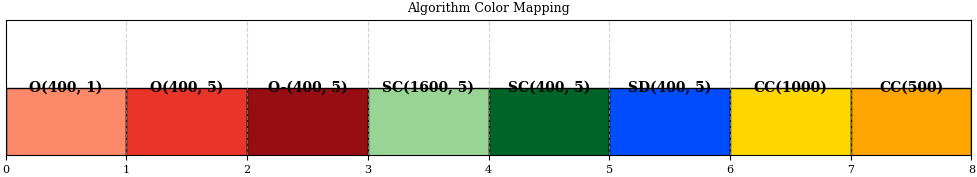

In [8]:
alg_names = df_times['alg'].unique()
alg_colors = make_colormap(alg_names)


Plotting time plots by task type...


bin task: N=30 per algorithm


/tmp/ipykernel_3399051/706906929.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_algs, fontsize=12)  # Increased from 9 to 12 (30% increase)
/tmp/ipykernel_3399051/706906929.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_algs, fontsize=12)  # Increased from 9 to 12 (30% increase)


follow task: N=30 per algorithm
reach task: N=60 per algorithm


/tmp/ipykernel_3399051/706906929.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_algs, fontsize=12)  # Increased from 9 to 12 (30% increase)
/tmp/ipykernel_3399051/706906929.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_overall.set_xticklabels(sorted_algs_overall, fontsize=12)  # Increased from 9 to 12


Plot saved as by_task_time_plots_hz.pdf


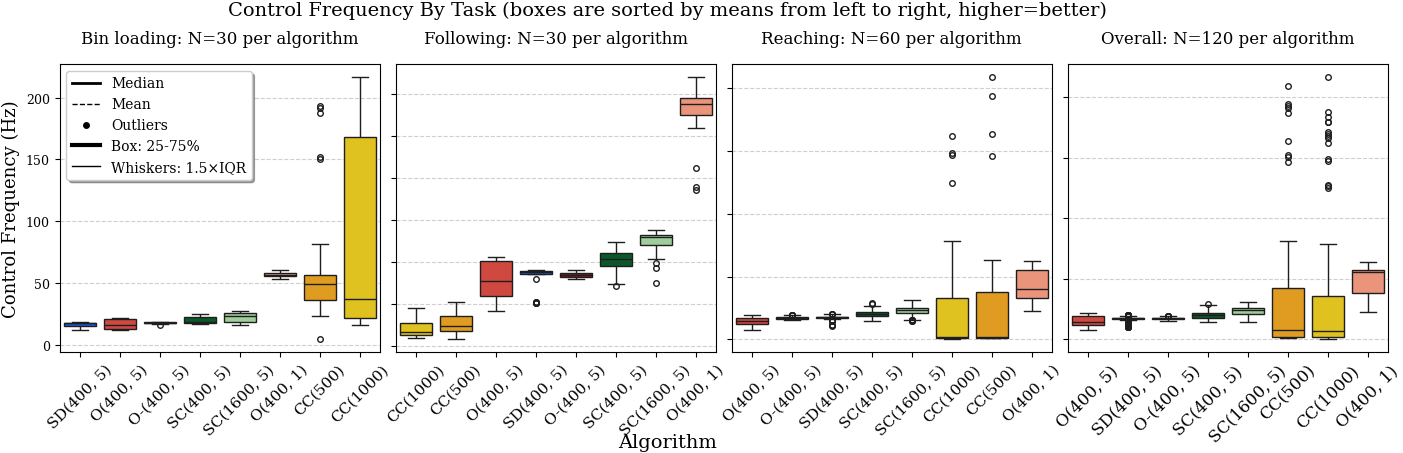

Plotting time plots combined...
Plotting time plots overall...


/tmp/ipykernel_3399051/706906929.py:208: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_planning_time, x='alg', y=y_col, ax=ax, showfliers=True, order=sorted_algs, palette=colormap)
/tmp/ipykernel_3399051/706906929.py:213: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_algs, fontsize=11)  # Increased from default to 12


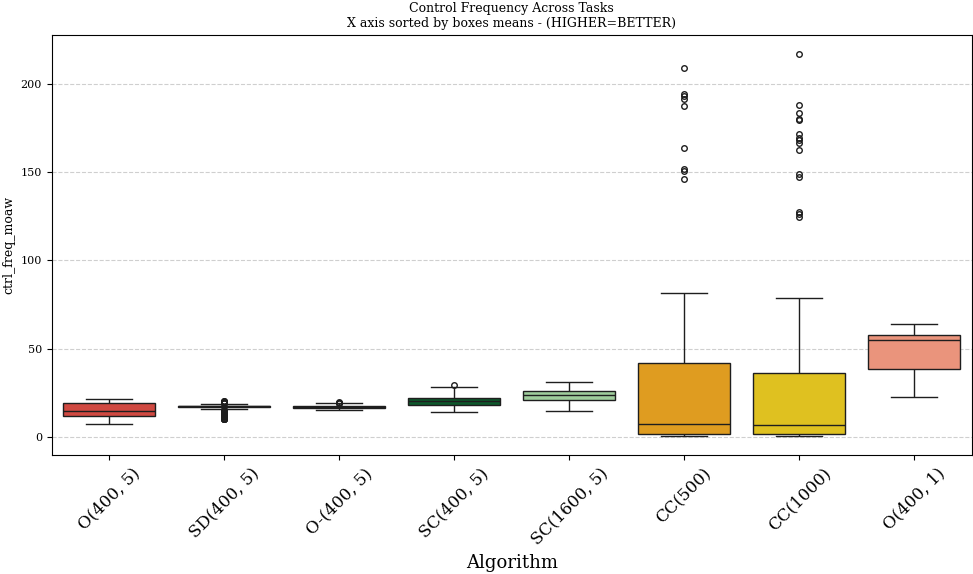

In [9]:
if time_analysis:
    print('Plotting time plots by task type...')
    make_time_plots(df_times, hz=True, mode='by_task',save=True,colormap=alg_colors)
    print('Plotting time plots combined...')
    # make_time_plots(df_times, hz=True, mode='combined',save=False,colormap=alg_colors)
    print('Plotting time plots overall...')
    make_time_plots(df_times, hz=True, mode='overall',save=False,colormap=alg_colors)


# 2. Analyze tasks and Safety

In [10]:
if task_analysis:
    mem_usage_before_loading = get_memory_usage()
    valid_sim_dir_paths, valid_sim_names, valid_sim_pkl_paths = find_valid_sims_for_loading(root_paths_task_analysis, verbose=verbose) # checking input dirs
    reach_sims, bin_sims, follow_sims, disk_sims = load_and_process_sim_files(valid_sim_pkl_paths, valid_sim_dir_paths, batch_size=BATCH_SIZE)
    all_sims = bin_sims + reach_sims + follow_sims + disk_sims
    print(f'Loading finished:')
    print(f'  Reach simulations: {len(reach_sims)}')
    print(f'  Bin simulations: {len(bin_sims)}')
    print(f'  Follow simulations: {len(follow_sims)}')
    print(f'  Disk simulations: {len(disk_sims)}')  
    print(f'  Total: {len(all_sims)}')
    print(f'Mem Usage Before Loading:{mem_usage_before_loading:.1f} MB. Mem Usage After Loading: {get_memory_usage():.1f} MB')

Checking if SC/N800_H40_cov005 is in /home/evrond/analysis_data/final_analysis/0709/500ts/time_task_collision/O/N400_H40_cov05_trust3_w5000_th03_1optIter/2025-09-08_03:30:27_R_ur5e_N4_AO_Tbin_s5_l2/stats.pkl
Checking if SC/N800_H40_cov005 is in /home/evrond/analysis_data/final_analysis/0709/500ts/time_task_collision/O/N400_H40_cov05_trust3_w5000_th03_1optIter/2025-09-08_07:14:33_R_ur5e_N4_AO_Treach_s0_l10/stats.pkl
Checking if SC/N800_H40_cov005 is in /home/evrond/analysis_data/final_analysis/0709/500ts/time_task_collision/O/N400_H40_cov05_trust3_w5000_th03_1optIter/2025-09-08_05:48:45_R_ur5e_N4_AO_Treach_s2_l5/stats.pkl
Checking if SC/N800_H40_cov005 is in /home/evrond/analysis_data/final_analysis/0709/500ts/time_task_collision/O/N400_H40_cov05_trust3_w5000_th03_1optIter/2025-09-08_07:17:54_R_ur5e_N4_AO_Treach_s1_l10/stats.pkl
Checking if SC/N800_H40_cov005 is in /home/evrond/analysis_data/final_analysis/0709/500ts/time_task_collision/O/N400_H40_cov05_trust3_w5000_th03_1optIter/2025-0

### Start the parsing (df making)

In [11]:
def analyze_tasks(all_sims,n_arm_max_for_follow=8):
    
    df_cols_shared = ['alg', 'task_level','task_seed', 'n_arms','wsteps_total','sim_id']

    
    task_specific_cols_bin = ['picked_total','placed_total']
    task_specific_cols_reach = ['reached_total','changed_total']
    
    task_specific_cols_follow = ['w_step'] + [f'arm_{k}_p_err' for k in range(n_arm_max_for_follow)] + [f'arm_{k}_q_err' for k in range(n_arm_max_for_follow)]
    bin_cols = df_cols_shared + task_specific_cols_bin
    bin_rows = []
    reach_cols = df_cols_shared + task_specific_cols_reach
    reach_rows = []
    follow_cols = df_cols_shared + task_specific_cols_follow
    df_follow = pd.DataFrame(columns=follow_cols)

    successfull_parsing_bin = []
    successfull_parsing_reach = []
    successfull_parsing_follow = []


    for i,sim in enumerate(all_sims):
        #if True:
        try:
            # for sim_idx, sim in enumerate(all_sims):
            task_df = sim.task_df
            alg = sim.meta_data['alg']
            task_level = sim.meta_data['task_level']
            n_arms = sim.meta_data['n_arms']
            seed = sim.meta_data['task_seed']
            sim_id = sim.meta_data['timestamp']
            w_steps_total = task_df['w_step'].max()

            arm_col_names = [c for c in task_df.columns if c.startswith('arm_')]
            df_tmp = sim.task_df.copy()[['w_step',*arm_col_names]]
            
            row = [alg, task_level, seed, n_arms, w_steps_total, sim_id]
            if sim.meta_data['task_type'] == 'bin':            
                df_tmp_last_step = df_tmp[df_tmp['w_step'] == w_steps_total]
                if df_tmp_last_step.shape[0] > 1:
                    print(f'warning for sim:')
                    print(sim)
                    print(f'more than one row in df_tmp_last_step')
                    print(df_tmp_last_step)
                
                df_last_step = df_tmp_last_step.iloc[0] # take the first row from last step
                # for c in df_last_step:
                #     print(f'ssssd')
                #     print(type(c))
                #     tp_in = 'total_picks' in c
                #     print(f'{c} in total_picks: {tp_in}')
                total_picked_cols = []
                total_placed_cols = []
                for c in df_tmp_last_step.columns:
                    if 'total_picks' in str(c):
                        total_picked_cols.append(c)
                    if 'total_drops' in str(c):
                        total_placed_cols.append(c)
                # total_picked_cols = [c for c in df_tmp_last_step.columns if 'total_picks' in c] # for each arm
                # total_placed_cols = [c for c in df_tmp_last_step.columns if 'total_drops' in c] # for each arm
                # print(df_last_step)
                if len(total_picked_cols) > 0:
                    total_picked_alg = df_last_step[total_picked_cols].sum()
                else:
                    continue
                if len(total_placed_cols) > 0:
                    total_placed_alg = df_last_step[total_placed_cols].sum()
                else:
                    continue

                row.extend([total_picked_alg, total_placed_alg])
                
                row_list = bin_rows
                success_list = successfull_parsing_bin
                
            elif sim.meta_data['task_type'] == 'reach':
                df_tmp_last_step = df_tmp[df_tmp['w_step'] == w_steps_total]                
                pd_series_last_step = df_tmp_last_step.iloc[0]
                sum_reached = 0
                sum_changed = 0
                for k in pd_series_last_step.keys():
                    if 'total_reached' in k:
                        sum_reached += pd_series_last_step[k]
                    elif 'total_changed' in k:
                        sum_changed += pd_series_last_step[k]
                row.extend([sum_reached, sum_changed])
                
                row_list = reach_rows
                success_list = successfull_parsing_reach
            
            elif sim.meta_data['task_type'] == 'follow':
                # task_specific_cols_follow = [f'arm_{k}_p_err' for k in range(n_arms)] + [f'arm_{k}_q_err' for k in range(n_arms)]                
                cur_follow_df = task_df[['w_step', *[c for c in task_df.columns if 'err' in c]]] # p,q err for each arm
                this_sim_follow_df = pd.DataFrame(columns=follow_cols)

                for k in range(n_arms):
                    p_err_col = f'arm_{k}_p_err'
                    q_err_col = f'arm_{k}_q_err'
                    cur_col_name = f'arm_{k}_err'
                    this_sim_follow_df[p_err_col] = cur_follow_df[cur_col_name].apply(lambda x: x[0])
                    this_sim_follow_df[q_err_col] = cur_follow_df[cur_col_name].apply(lambda x: x[1])
                    this_sim_follow_df['w_step'] = cur_follow_df['w_step']
                
                this_sim_follow_df['alg'] = alg
                this_sim_follow_df['task_level'] = task_level
                this_sim_follow_df['task_seed'] = seed
                this_sim_follow_df['n_arms'] = n_arms
                this_sim_follow_df['wsteps_total'] = w_steps_total
                this_sim_follow_df['sim_id'] = sim_id
                

                df_follow = pd.concat([df_follow, this_sim_follow_df])
                row_list = None
                success_list = successfull_parsing_follow
                
            else:
                raise ValueError(f'task type not supported: {sim.meta_data["task_type"]}')

            if row_list is not None:
                row_list.append(row)
            success_list.append(i)
        
        except Exception as e:
            print(f'error on sim:')
            print(sim)
            print(f'error: {e}')
            print('-'*100)
            continue

    df_bin = pd.DataFrame(bin_rows, columns=bin_cols)
    df_reach = pd.DataFrame(reach_rows, columns=reach_cols)
    # df follow post processing
    p_err_cols = [c for c in df_follow.columns if 'p_err' in c]
    df_follow['p_err_mean'] = df_follow[p_err_cols].mean(axis=1)
    p_err_var = df_follow[p_err_cols].var(axis=1)
    df_follow['p_err_var'] = p_err_var
    q_err_cols = [c for c in df_follow.columns if 'q_err' in c]
    df_follow['q_err_mean'] = df_follow[q_err_cols].mean(axis=1)
    q_err_var = df_follow[q_err_cols].var(axis=1)
    df_follow['q_err_var'] = q_err_var
    return (df_bin,successfull_parsing_bin), (df_reach,successfull_parsing_reach), (df_follow,successfull_parsing_follow)




In [12]:
if task_analysis:
    bin, reach, follow = analyze_tasks(all_sims)

warning for sim:

timestamp: 2025-09-08_03:52:13
robot_name: ur5e
n_arms: 4
alg: O(400, 1)
task_type: bin
task_seed: 0
task_level: 4
particle_cfg: {'cost': {'bound_cfg': {'activation_distance': [0.1, 0.1, 0.1, 0.1], 'null_space_weight': [10.0], 'run_weight_acceleration': 1.0, 'run_weight_jerk': 1.0, 'run_weight_velocity': 0.0, 'smooth_weight': [0.0, 50.0, 0.0, 0.0], 'weight': [5000.0, 5000.0, 5000.0, 0.0]}, 'cspace_cfg': {'run_weight': 1.0, 'terminal': True, 'weight': 1000.0}, 'custom': {'arm_base': {'dynamic_obs_cost': {'a_select_mode': 'normal', 'class_name': 'DynamicObsCost', 'config_class_name': 'DynamicObsCostConfig', 'module_path': 'curobo.rollout.cost.custom.arm_base.dynamic_obs_cost', 'prior_keep_lower_bound': 0.0, 'prior_p_err_impact_rad': 0.1, 'prior_pos_to_rot_ratio': 1.0, 'prior_rot_err_impact_angle': 180, 'prior_rule': 'pose_wta', 'prior_weight_mode': 'exponential', 'safety_margin': 0.3, 'sparse_spheres': {'use': True}, 'sparse_steps': {'ratio': 0.2, 'use': False}, 'termin

/tmp/ipykernel_3399051/2234933407.py:112: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_follow = pd.concat([df_follow, this_sim_follow_df])


### Final reasults of task-dfs making

In [13]:
if task_analysis:
    df_bin, df_reach, df_follow = bin[0], reach[0], follow[0]
    successfull_parsing_bin, successfull_parsing_reach, successfull_parsing_follow = bin[1], reach[1], follow[1]
    print(f'In total: {len(successfull_parsing_bin)} bin tasks parsed successfully')
    print(f'In total: {len(successfull_parsing_reach)} reach tasks parsed successfully')
    print(f'In total: {len(successfull_parsing_follow)} follow tasks pardsed successfully')


In total: 240 bin tasks parsed successfully
In total: 480 reach tasks parsed successfully
In total: 240 follow tasks pardsed successfully


### Show snippets of tasks datasets

#### Bin task df legend
- wsteps_total: final world step in the simulation
- picked_total: sum of all items which have been picked in total (by the end of the simulation), over all arms.
- placed total- sum of all items which have been placed in total (by the end of the simulation), over all arms (must be <= picked total since placing occures only after picking) 


In [14]:
df_bin.tail() if (task_analysis and verbose) else ''

''

#### Follow task df legend
- w_step: current step number in the simulation (world step)
- wsteps_total: final world step in the simulation
- arm_%i%_p_err: position error between end effector of arm i to the target of arm i (in meters, norm over x,y,z axis). 
- arm_%i%_q_err: oreientation mean orientation error in degrees, over the 3 rotation axis (roll, pitch, yaw) between the end effector of arm i to the target of arm i  

In [15]:
df_follow.tail() if (task_analysis and verbose) else ''

''

#### Reach task df legend

- changed_total: Num of allocated targets in total (sum over all arms)
- reached_total: Num of targets arms reached (sum over all arms)


In [16]:
df_reach.tail() if (task_analysis and verbose) else ''

''

In [17]:
if (task_analysis and verbose):
    bin_task_sanity_check(df_bin)


# Analyze Safety

In [18]:
def analyze_collisions(all_sims):
    """
    Analyze collision data from simulations and return two dataframes:
    1. df_collisions: Summary statistics per simulation
    2. df_collision_extended: Detailed step-by-step collision data
    """
    
    def check_rrc_rre_for_agent(df):
        w_steps_in_rrc = set()
        w_steps_in_rre = set()
        agent_world_col_world_steps = df[df.env_cols == True]['w_step']
        agent_arm_col_world_steps = df[df.arm_cols == True]['w_step']

        for w_step in agent_world_col_world_steps:
            w_steps_in_rrc.add(w_step)
        for w_step in agent_arm_col_world_steps:
            w_steps_in_rre.add(w_step)

        return w_steps_in_rrc, w_steps_in_rre

    # Define columns for df_collisions
    columns = ['alg', 'n_arms', 
    'wstep_total', 'task_type', 
    'task_level', 
    'rre_n', # sum over all robots and all steps of I(i,j) where I(i,t) is 1 if robot i is in collision with environment at step t  
    'rrc_n', #  sum over all robots and all steps of I(i,j) where I(i,t) is 1 if robot i is in collision with another robot at time t 
    'rrc_chance', 
    'rre_chance', 
    'task_seed',
    'sim_id']
    
    rows = []
    extended_rows = []
    successfull_parsing = []
    unsuccessfull_parsing = []
    
    for sim in all_sims:
        try:
            centralized = sim.is_centralized()
            agents_dfs = sim.get_agents_dfs()
            sim_id = sim.meta_data['timestamp']
            
            if centralized:
                df = sim.get_agents_dfs()[0]
                n_steps = df.w_step.max()
                rre_cols, rrc_cols = check_rrc_rre_for_agent(df)
                rre_n = len(rre_cols)
                rrc_n = len(rrc_cols)
                # print('rrc_n:', rrc_n)
                # print('rre_n:', rre_n)
                
                # Create extended rows for centralized case
                for _, row in df.iterrows():
                    extended_rows.append([
                        sim_id,
                        row['w_step'],
                        row['env_cols'] == True if pd.notna(row['env_cols']) else False,
                        row['arm_cols'] == True if pd.notna(row['arm_cols']) else False
                    ])
                    
            else:
                # list of dfs one for each agent (arm)
                w_steps_in_rrc = set()
                w_steps_in_rre = set()
                n_steps = 0    
                for df in agents_dfs:
                    rre_n, rrc_n = check_rrc_rre_for_agent(df)
                    w_steps_in_rrc = set.union(w_steps_in_rrc, rrc_n)
                    w_steps_in_rre = set.union(w_steps_in_rre, rre_n)
                    n_steps = max(n_steps, df.w_step.max())
                    
                    # Create extended rows for decentralized case
                    for _, row in df.iterrows():
                        extended_rows.append([
                            sim_id,
                            row['w_step'],
                            row['env_cols'] == True if pd.notna(row['env_cols']) else False,
                            row['arm_cols'] == True if pd.notna(row['arm_cols']) else False
                        ])
                        
                rre_n = len(w_steps_in_rre)
                rrc_n = len(w_steps_in_rrc)

            rre_chance = rre_n / n_steps
            rrc_chance = rrc_n / n_steps
            rows.append([sim.meta_data['alg'], sim.meta_data['n_arms'], n_steps, sim.meta_data['task_type'],sim.meta_data['task_level'], rre_n, rrc_n, rrc_chance, rre_chance,sim.meta_data['task_seed'], sim.meta_data['timestamp']])
            successfull_parsing.append(sim)

        except Exception as e:
            unsuccessfull_parsing.append((sim,e))

    print_parsing_summary(successfull_parsing, unsuccessfull_parsing)

    # Create dataframes
    df_collisions = pd.DataFrame(rows, columns=columns)
    df_collision_extended = pd.DataFrame(extended_rows, columns=['sim_id', 'w_step', 'in_rec', 'in_rrc'])
    
    return df_collisions, df_collision_extended, successfull_parsing, unsuccessfull_parsing
def create_collision_intervals(df_collision_extended):
    """
    Create collision intervals from the extended collision dataframe.
    
    Args:
        df_collision_extended: DataFrame with columns ['sim_id', 'w_step', 'in_rec', 'in_rrc']
    
    Returns:
        DataFrame with columns ['sim_id', 'col_interval_start_time', 'col_interval_end_time']
    """
    intervals = []
    
    # Group by simulation ID
    for sim_id, group in df_collision_extended.groupby('sim_id'):
        # Sort by w_step to ensure proper ordering
        group = group.sort_values('w_step').reset_index(drop=True)
        
        # Create a combined collision column (True if either in_rec or in_rrc is True)
        group['in_collision'] = group['in_rec'] | group['in_rrc']
        
        # Find collision intervals
        in_interval = False
        interval_start = None
        
        for i, row in group.iterrows():
            if row['in_collision'] and not in_interval:
                # Start of new collision interval
                interval_start = row['w_step']
                in_interval = True
            elif not row['in_collision'] and in_interval:
                # End of collision interval - find the previous step
                if i > 0:
                    prev_step = group.iloc[i-1]['w_step']
                    intervals.append({
                        'sim_id': sim_id,
                        'col_interval_start_time': interval_start,
                        'col_interval_end_time': prev_step
                    })
                in_interval = False
                interval_start = None
        
        # Handle case where collision interval extends to the end of simulation
        if in_interval and interval_start is not None:
            intervals.append({
                'sim_id': sim_id,
                'col_interval_start_time': interval_start,
                'col_interval_end_time': group['w_step'].max()
            })
    
    return pd.DataFrame(intervals)




def make_overall_df(df_collisions,successfull_parsing,sim_paths,colfree_only=False):
    """
    Make a dataframe with all the data from the experiments.
    The dataframe contains the following columns:
    - sim_id: the id of the simulation
    - alg: the algorithm used
    - task_type: the type of task
    - task_level: the level of the task
    - task_seed: the seed of the task
    - task_score_reach: the score of the reach task or 0 if the task is not a reach task
    - task_score_bin: the score of the bin task or 0 if the task is not a bin task
    - task_score_follow: the score of the follow task or 0 if the task is not a follow task
    
    - safety_score_rrc: the score of the rrc safety metric (1 - (N collisions / N world steps total))
    - safety_score_rec: the score of the rec safety metric (1 - (N collisions / N world steps total))
    - task_score: the score of the task (sum of task_score_reach, task_score_bin, task_score_follow). Only the task score is considered (the other 2 tasks are 0)
    - overall_score: the overall score (task_score * score_weights_TER[0] + safety_score_rec * score_weights_TER[1] + safety_score_rrc * score_weights_TER[2])
    
    
    """
    import yaml
    overall_df = df_collisions.copy()
    overall_df[['weight','trust','cov']] = -1,-1,-1 # add columns for tuning
    for sim in successfull_parsing:
        sim_id = sim.meta_data['timestamp']
        all_sims = sim_paths
        for dir_path in all_sims:
            if sim_id in dir_path:
                
                # Add meta data and task specific columns
                overall_df.loc[overall_df['sim_id'] == sim_id, 'alg'] = sim.meta_data['alg']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_type'] = sim.meta_data['task_type']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_level'] = sim.meta_data['task_level']
                overall_df.loc[overall_df['sim_id'] == sim_id, 'task_seed'] = sim.meta_data['task_seed']
                
                task_type = sim.meta_data['task_type']
                if task_type == 'reach':
                    
                    
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'changed_total'] = \
                          df_reach[df_reach['sim_id'] == sim_id]['changed_total'].values[0]
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'reached_total'] =\
                        df_reach[df_reach['sim_id'] == sim_id]['reached_total'].values[0]

                    
                elif task_type == 'follow':
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_mean_arms_wsteps'] = \
                        df_follow[df_follow['sim_id'] == sim_id]['p_err_mean'].mean() # taking the mean over arms and making a mean over w_steps
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'p_err_var_arms_wsteps'] = \
                        df_follow[df_follow['sim_id'] == sim_id]['p_err_var'].mean() # taking the var over arms and making a mean over w_steps
                elif task_type == 'bin':
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'picked_total'] = \
                        df_bin[df_bin['sim_id'] == sim_id]['picked_total'].values[0]
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'placed_total'] = \
                        df_bin[df_bin['sim_id'] == sim_id]['placed_total'].values[0]
                    

                else:
                    raise ValueError(f'Task type {sim.meta_data["task_type"]} not supported')
                
                # Add tuning parameters if they exist
                tuning_path = os.path.join(dir_path, 'particle_cfg.yml')
                if not os.path.exists(tuning_path):
                    continue
                with open(tuning_path, 'r') as f:
                    particle_cfg = yaml.load(f, Loader=yaml.FullLoader)
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'weight'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['weight']
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'trust'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['wta_trust']
                    overall_df.loc[overall_df['sim_id'] == sim_id, 'cov'] = particle_cfg['mppi']['init_cov']
        

    try:
        overall_df['task_score_reach'] = overall_df['reached_total'] / overall_df['reached_total'].max()
    except:
        overall_df['task_score_reach'] = 0
    try:
        overall_df['task_score_bin'] = overall_df['placed_total']  / overall_df['placed_total'].max()
    except:
        overall_df['task_score_bin'] = 0

    try:
        normalized_sim_follow_mean_error =  (overall_df['p_err_mean_arms_wsteps'] - overall_df['p_err_mean_arms_wsteps'].min()) / (overall_df['p_err_mean_arms_wsteps'].max() - overall_df['p_err_mean_arms_wsteps'].min()) 
        overall_df['task_score_follow'] = 1 - normalized_sim_follow_mean_error 
    except:
        overall_df['task_score_follow'] = 0

    overall_df['safety_score_rrc'] = 1 - overall_df['rrc_chance']
    overall_df['safety_score_rec'] = 1 - overall_df['rre_chance']

    if colfree_only: # only keep colfree simulations
        overall_df = overall_df[(overall_df['rrc_chance'] == 0.0) & (overall_df['rre_chance'] == 0.0)]
    
    # Fill NaNs with 0 at the tasks which are not run
    overall_df[['task_score_reach','task_score_bin','task_score_follow']] = \
        overall_df[['task_score_reach','task_score_bin','task_score_follow']].fillna(0) 
    
    overall_df['task_score'] = overall_df[['task_score_reach','task_score_bin','task_score_follow']].sum(axis=1) # just the task score (other 2 tasks are 0)
    return overall_df

def show_histogram_of_tasks(overall_df):
    # Histogram of the follow task score
    try:
        fig, axs = plt.subplots(1, 3, figsize=(18, 5))

        # Histogram for task_score_reach
        axs[0].hist(overall_df[overall_df.task_type == 'reach']['reached_total'], bins=20, color='skyblue', edgecolor='black')
        axs[0].set_title('Reach Task')
        axs[0].set_xlabel('N goals reached in total (all arms)')
        axs[0].set_ylabel('Count')

        # Histogram for task_score_bins
        axs[1].hist(overall_df[overall_df.task_type == 'bin']['placed_total'], bins=20, color='lightgreen', edgecolor='black')
        axs[1].set_title('Bin Task')
        axs[1].set_xlabel('N items placed in total (all arms)')
        axs[1].set_ylabel('Count')

        # Histogram for task_score_follow
        axs[2].hist(overall_df[overall_df.task_type == 'follow']['p_err_mean_arms_wsteps'], bins=20, color='salmon', edgecolor='black')
        axs[2].set_title('Follow Task')
        axs[2].set_xlabel('mean (over entire simulation steps) EE position error')
        axs[2].set_ylabel('Count')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f'Error: {e}')
        pass




def get_score_column(task_type):
    if task_type == 'reach':
        return 'reached_total'
    elif task_type == 'bin':
        return 'placed_total'
    elif task_type == 'follow':
        return 'p_err_mean_arms_wsteps'


def get_ylabel(task_type):
    if task_type == 'reach':
        return 'N goals reached in total (all arms)'
    elif task_type == 'bin':
        return 'N items placed in total (all arms)'
    elif task_type == 'follow':
        return 'Mean EE position error (m)'




In [19]:
if task_analysis:
    all_sims = bin_sims + reach_sims + follow_sims
    df_collisions, df_collision_extended, successfull_parsing, unsuccessfull_parsing = analyze_collisions(all_sims) # heavy


parsing summary:
successfull_parsing: 960
unsuccessfull_parsing: 0
to view errors, see unsuccessfull_parsing[i][1] for error message


In [ ]:
def analyze_and_plot_collision_chances(df_collisions, by_task=False, split_reach=False, colormap=None, save=False):
    """
    Complete analysis and plotting of collision chances by algorithm.
    
    Args:
        df_collisions: DataFrame with collision summary statistics
        by_task: If True, show results broken down by task type
        split_reach: If True and by_task is True, split 'reach' tasks into 'reach(easy)' and 'reach(hard)' based on task_level
        colormap: Optional colormap for consistent algorithm colors across all plots.
        save: If True, save the plot to PDF
    
    Returns:
        DataFrame with sim_id, alg, and col_chance columns (and task_type if by_task=True)
    """

    # Create a copy to avoid modifying original
    df_analysis = df_collisions.copy()
    
    # Calculate collision chance as min(1, rrc_chance + rre_chance)
    df_analysis['col_chance'] = df_analysis.apply(
        lambda row: min(1.0, row['rrc_chance'] + row['rre_chance']), axis=1
    )
    
    # Define a consistent color palette for algorithms
    if colormap is not None:
        # Use provided colormap (should be a dict mapping alg names to colors)
        alg_colors = colormap
    else:
        alg_palette = sns.color_palette("husl", n_colors=len(df_analysis['alg'].unique()))
        alg_colors = {alg: color for alg, color in zip(sorted(df_analysis['alg'].unique()), alg_palette)}
    
    # Create clean legend elements (shared across all modes)
    # legend_elements = [
    #     Line2D([0], [0], color='black', lw=2, label='Median'),
    #     Line2D([0], [0], color='black', lw=1, ls='--', label='Mean'),
    #     Line2D([0], [0], marker='o', color='w', label='Outliers',
    #           markerfacecolor='black', markersize=6),
    #     Line2D([0], [0], color='black', lw=3, label='Box: 25-75%'),
    #     Line2D([0], [0], color='black', lw=1, label='Whiskers: 1.5×IQR'),
    # ]
    legend_elements = [
    Line2D([0], [0], color='black', lw=2, label='Median'),
    Line2D([0], [0], color='black', lw=1, ls='--', label='Mean'),
    Line2D([0], [0], marker='o', color='w', label='Outliers',
          markerfacecolor='black', markersize=6),
    Line2D([0], [0], color='black', lw=3, label='Box: 25-75%'),
    Line2D([0], [0], color='black', lw=1, label='Whiskers: 1.5×IQR'),
    Line2D([0], [0], marker='s', color='black', lw=0, markersize=8, label='Combined Score(△)'),  # Add this line
    ]
    from matplotlib.patches import Patch
    shared_legend_elements = [
        Patch(facecolor='gray', alpha=0.7, label='Task Score(higher=better)'),
        Patch(facecolor='gray', alpha=0.5, hatch='///', label='Collision Chance(lower=better)'),
        Line2D([0], [0], marker='s', color='black', lw=0, markersize=8, label='Combined Score(△) (higher=better)'),  # Changed from red triangle to black square
    ]
    if by_task:
        # Split 'reach' tasks if split_reach is True
        if split_reach:
            df_analysis.loc[(df_analysis['task_type'] == 'reach') & (df_analysis['task_level'] <= 5), 'task_type'] = 'reach(easy)'
            df_analysis.loc[(df_analysis['task_type'] == 'reach') & (df_analysis['task_level'] > 5), 'task_type'] = 'reach(hard)'
        
        # Create the result dataframe with task type included
        result_df = df_analysis[['sim_id', 'alg', 'task_type', 'col_chance']].copy()
        
        # Create subplots for each task type + overall (4 subplots total) - square subplots
        task_types = result_df['task_type'].unique()
        n_tasks = len(task_types)
        
        fig, axes = plt.subplots(1, n_tasks + 1, figsize=(5*(n_tasks + 1), 5))  # Square subplots
        if n_tasks == 1:
            axes = [axes[0], axes[1]]
        
        # Add overall figure title (centered)
        fig.suptitle("Collision Chances by Algorithm (sorted in decreasing order along x, higher=better)", fontsize=14, y=1.02)
        
        # Plot each task type in its own subplot
        for i, task_type in enumerate(task_types):
            ax = axes[i]
            task_data = result_df[result_df['task_type'] == task_type]
            
            # Calculate MEAN collision chance for each algorithm and sort (decreasing order)
            means = task_data.groupby('alg')['col_chance'].mean().sort_values(ascending=False)
            sorted_algs = means.index.tolist()
            
            # Create box plot for this task with sorted algorithms
            sns.boxplot(
                data=task_data, 
                x='alg', 
                y='col_chance', 
                ax=ax,
                order=sorted_algs,
                palette=alg_colors
            )
            
            # Calculate N per algorithm
            n_per_alg = len(task_data[task_data['alg'] == sorted_algs[0]]) if sorted_algs else 0
            
            # Customize the plot
            task_title_map = {
                'reach': 'Reaching',
                'reach(easy)': 'Reaching (easy)',
                'reach(hard)': 'Reaching (hard)',
                'bin': 'Bin loading', 
                'follow': 'Following'
            }
            task_display_name = task_title_map.get(task_type, task_type.title())
            ax.set_title(f"{task_display_name}: N={n_per_alg} per algorithm", 
                        fontsize=12, pad=15)
            ax.set_xlabel('Algorithm', fontsize=10)
            ax.set_ylabel('Collision Chance', fontsize=10)
            ax.set_ylim(0, 1)
            
            # Increase tick label sizes and rotate x-axis labels
            ax.tick_params(axis='x', labelsize=9, rotation=45)
            ax.tick_params(axis='y', labelsize=9)
            
            # Add grid
            ax.grid(True, alpha=0.3, linestyle='--')
            
            # Add clean legend only to the first subplot, positioned at top-left
            if i == 0:
                ax.legend(handles=legend_elements, 
                        bbox_to_anchor=(0, 1),  # Top-left position
                        loc='upper left',
                        fontsize=8,
                        frameon=True,
                        fancybox=True,
                        shadow=True)
        
        # Create overall plot (rightmost subplot)
        ax_overall = axes[-1]  # Last subplot
        
        # Calculate overall means for each algorithm across all tasks
        overall_means = result_df.groupby('alg')['col_chance'].mean().sort_values(ascending=False)
        sorted_algs_overall = overall_means.index.tolist()
        
        # Calculate N per algorithm for overall plot
        n_per_alg_overall = len(result_df[result_df['alg'] == sorted_algs_overall[0]]) if sorted_algs_overall else 0
        
        # Create overall boxplot
        sns.boxplot(
            data=result_df, 
            x='alg', 
            y='col_chance', 
            ax=ax_overall,
            order=sorted_algs_overall,
            palette=alg_colors,
        )
        
        # Customize the overall plot
        ax_overall.set_title(f"Overall: N={n_per_alg_overall} per algorithm", fontsize=12, pad=15)
        ax_overall.set_xlabel('Algorithm', fontsize=10)
        ax_overall.set_ylabel('Collision Chance', fontsize=10)
        ax_overall.set_ylim(0, 1)
        ax_overall.tick_params(axis='x', labelsize=9, rotation=45)
        ax_overall.tick_params(axis='y', labelsize=9)
        ax_overall.grid(True, alpha=0.3, linestyle='--')
        
        # Share y-axis (only show labels on leftmost plot)
        for i, ax in enumerate(axes):
            if i == 0:  # Leftmost plot
                ax.set_ylabel('Collision Chance', fontsize=10)
            else:  # All other plots
                ax.set_ylabel("")  # Remove y-label
                ax.tick_params(axis='y', left=True, labelleft=False)  # Keep ticks but no labels
        
        # Adjust layout to prevent legend cutoff and title overlap
        plt.tight_layout()
        plt.subplots_adjust(left=0.12, top=0.88, right=0.95)  # More space for title
        
        # Save PDF before showing
        if save:
            f_name = f"collision_chances_by_task"
            plt.savefig(f"{f_name}.pdf", bbox_inches='tight', dpi=300)
            print(f"Plot saved as {f_name}.pdf")
        
        plt.show()
        
        # Print summary statistics tables for each task
        print("="*80)
        print("Collision chances by algorithm by task type")
        print("="*80)
        
        for task_type in task_types:
            task_data = result_df[result_df['task_type'] == task_type]
            
            # Calculate summary statistics
            summary_stats = task_data.groupby('alg')['col_chance'].agg([
                'count', 'min', 'max', 'mean', 'std'
            ]).round(4)
            
            # Rename columns for better display
            summary_stats.columns = ['Count', 'Min', 'Max', 'Mean', 'Std Dev']
            
            print(f"\n{task_type.upper()} TASK:")
            print("-" * 50)
            print(summary_stats.to_string())
            print()
        
    else:
        # Original behavior - overall collision chances by algorithm
        result_df = df_analysis[['sim_id', 'alg', 'col_chance']].copy()
        
        # Calculate MEAN collision chance for each algorithm and sort (decreasing order)
        means = result_df.groupby('alg')['col_chance'].mean().sort_values(ascending=False)
        sorted_algs = means.index.tolist()
        
        # Create the plot with better proportions
        fig, ax = plt.subplots(figsize=(14, 10))
        
        # Create box plot with sorted algorithms and consistent colors
        sns.boxplot(
            data=result_df, 
            x='alg', 
            y='col_chance', 
            order=sorted_algs,
            palette=alg_colors
        )
        
        # Customize the plot with larger fonts and better spacing
        ax.set_title('Collision Chances by Algorithm (All Tasks)', fontsize=20, pad=20)
        ax.set_xlabel('Algorithm', fontsize=16)
        ax.set_ylabel('Collision Chance', fontsize=16)
        ax.set_ylim(0, 1)
        
        # Increase tick label sizes and rotate x-axis labels
        ax.tick_params(axis='x', labelsize=14, rotation=45)
        ax.tick_params(axis='y', labelsize=14)
        
        # Add grid for better readability
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Add clean legend
        ax.legend(handles=legend_elements, 
                 bbox_to_anchor=(1.05, 1), 
                 loc='upper left',
                 fontsize=10,
                 frameon=True,
                 fancybox=True,
                 shadow=True)
        
        # Adjust layout to prevent overlap
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.15, left=0.1, right=0.95, top=0.9)
        
        # Save PDF before showing
        if save:
            f_name = f"collision_chances_overall"
            plt.savefig(f"{f_name}.pdf", bbox_inches='tight', dpi=300)
            print(f"Plot saved as {f_name}.pdf")
        
        plt.show()
        
        # Print overall summary statistics table
        print("="*80)
        print("Collision chances over all tasks")
        print("="*80)
        
        # Calculate summary statistics
        summary_stats = result_df.groupby('alg')['col_chance'].agg([
            'count', 'min', 'max', 'mean', 'std'
        ]).round(4)
        
        # Rename columns for better display
        summary_stats.columns = ['Count', 'Min', 'Max', 'Mean', 'Std Dev']
        
        print(summary_stats.to_string())
        print()
    
    return result_df

## Comment out to plot

/tmp/ipykernel_3399051/2798404416.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3399051/2798404416.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3399051/2798404416.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3399051/2798404416.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3399051/2798404416.py:127: Fu

Plot saved as collision_chances_by_task.pdf


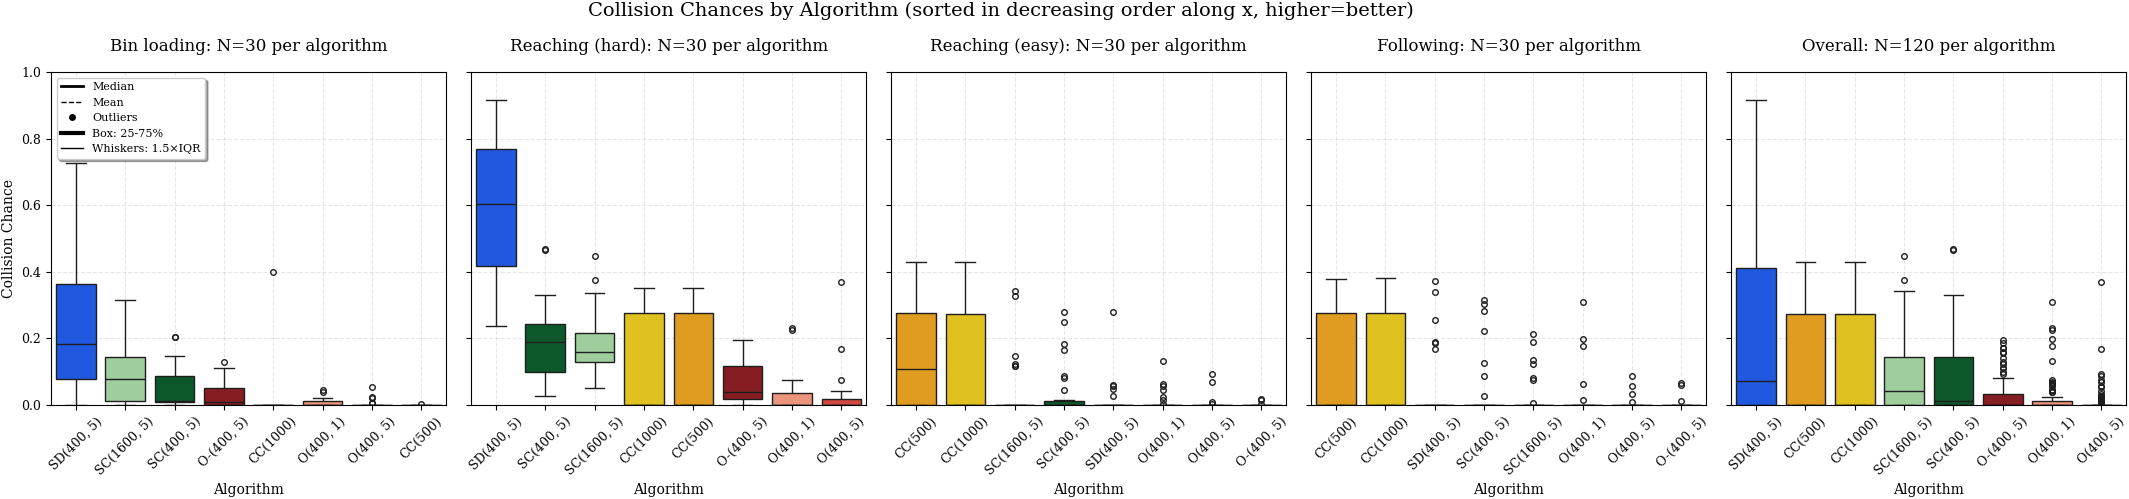

Collision chances by algorithm by task type

BIN TASK:
--------------------------------------------------
             Count  Min    Max    Mean  Std Dev
alg                                            
CC(1000)        30  0.0  0.400  0.0133   0.0730
CC(500)         30  0.0  0.004  0.0001   0.0007
O(400, 1)       30  0.0  0.044  0.0077   0.0121
O(400, 5)       30  0.0  0.054  0.0037   0.0112
O-(400, 5)      30  0.0  0.130  0.0303   0.0395
SC(1600, 5)     30  0.0  0.316  0.0841   0.0807
SC(400, 5)      30  0.0  0.204  0.0512   0.0631
SD(400, 5)      30  0.0  0.854  0.2552   0.2684


REACH(HARD) TASK:
--------------------------------------------------
             Count    Min    Max    Mean  Std Dev
alg                                              
CC(1000)        30  0.000  0.350  0.1252   0.1578
CC(500)         30  0.000  0.350  0.1252   0.1578
O(400, 1)       30  0.000  0.232  0.0289   0.0593
O(400, 5)       30  0.000  0.368  0.0265   0.0726
O-(400, 5)      30  0.000  0.196  0.0687   

,sim_id,alg,task_type,col_chance
0,2025-09-08_03:30:27,"O(400, 1)",bin,0.000
1,2025-09-08_04:01:24,"O(400, 1)",bin,0.022
2,2025-09-08_03:27:28,"O(400, 1)",bin,0.000
3,2025-09-08_04:23:09,"O(400, 1)",bin,0.000
4,2025-09-08_04:04:41,"O(400, 1)",bin,0.000
...,...,...,...,...
955,2025-09-08_22:54:49,CC(500),follow,0.000
956,2025-09-08_22:41:53,CC(500),follow,0.000
957,2025-09-08_22:22:11,CC(500),follow,0.000
958,2025-09-08_23:40:16,CC(500),follow,0.278


In [21]:


analyze_and_plot_collision_chances(df_collisions, by_task=True,colormap=alg_colors, split_reach=True,save=True) # OVER ALL TASKS
    
# Usage examples:
# Original plot
# make_task_success_plots(overall_df, normalize=False, add_subtotal_figure=False)

# With normalization
# make_task_success_plots(overall_df, normalize=True, add_subtotal_figure=False)

# With normalization and subtotal
# make_task_success_plots(overall_df, normalize=True, add_subtotal_figure=True)
    

/tmp/ipykernel_3399051/2798404416.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3399051/2798404416.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3399051/2798404416.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3399051/2798404416.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3399051/2798404416.py:127: Fu

Plot saved as collision_chances_by_task.pdf


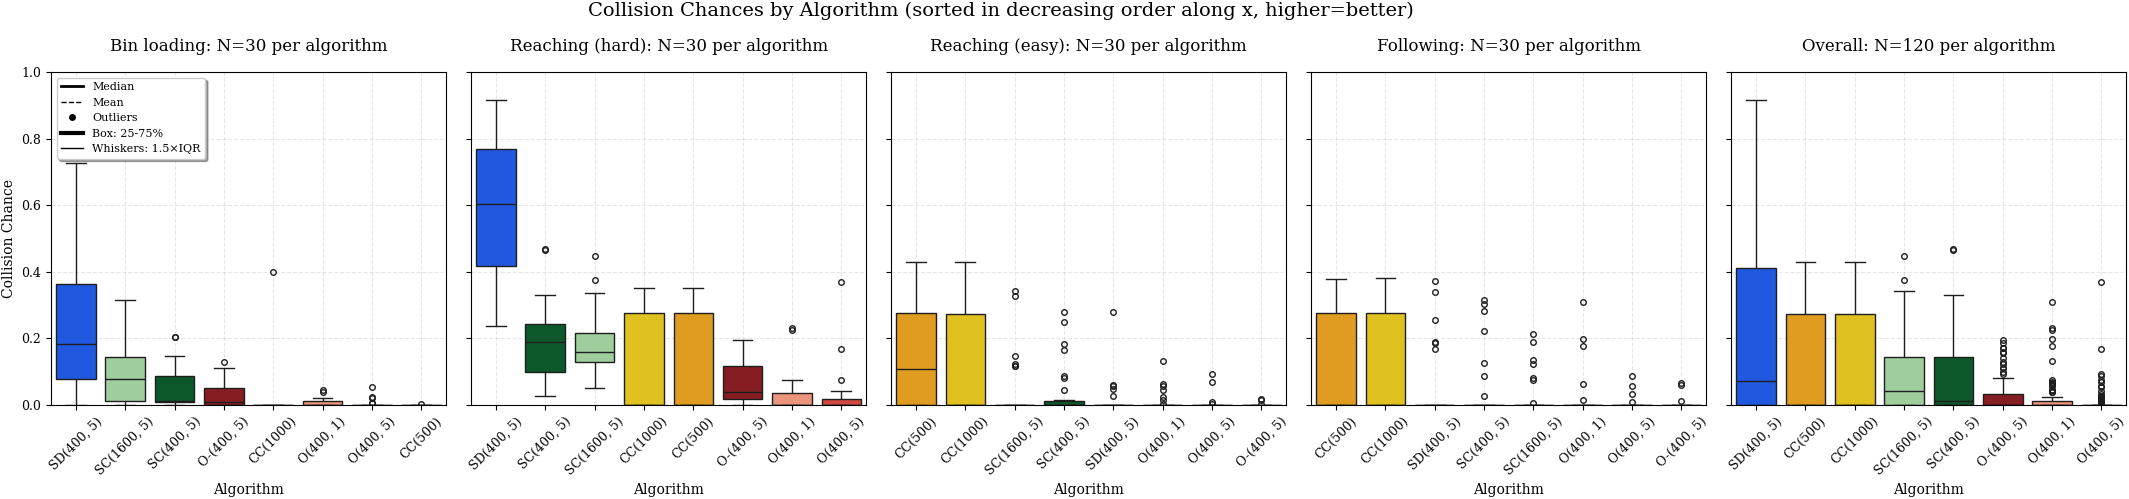

Collision chances by algorithm by task type

BIN TASK:
--------------------------------------------------
             Count  Min    Max    Mean  Std Dev
alg                                            
CC(1000)        30  0.0  0.400  0.0133   0.0730
CC(500)         30  0.0  0.004  0.0001   0.0007
O(400, 1)       30  0.0  0.044  0.0077   0.0121
O(400, 5)       30  0.0  0.054  0.0037   0.0112
O-(400, 5)      30  0.0  0.130  0.0303   0.0395
SC(1600, 5)     30  0.0  0.316  0.0841   0.0807
SC(400, 5)      30  0.0  0.204  0.0512   0.0631
SD(400, 5)      30  0.0  0.854  0.2552   0.2684


REACH(HARD) TASK:
--------------------------------------------------
             Count    Min    Max    Mean  Std Dev
alg                                              
CC(1000)        30  0.000  0.350  0.1252   0.1578
CC(500)         30  0.000  0.350  0.1252   0.1578
O(400, 1)       30  0.000  0.232  0.0289   0.0593
O(400, 5)       30  0.000  0.368  0.0265   0.0726
O-(400, 5)      30  0.000  0.196  0.0687   

,sim_id,alg,task_type,col_chance
0,2025-09-08_03:30:27,"O(400, 1)",bin,0.000
1,2025-09-08_04:01:24,"O(400, 1)",bin,0.022
2,2025-09-08_03:27:28,"O(400, 1)",bin,0.000
3,2025-09-08_04:23:09,"O(400, 1)",bin,0.000
4,2025-09-08_04:04:41,"O(400, 1)",bin,0.000
...,...,...,...,...
955,2025-09-08_22:54:49,CC(500),follow,0.000
956,2025-09-08_22:41:53,CC(500),follow,0.000
957,2025-09-08_22:22:11,CC(500),follow,0.000
958,2025-09-08_23:40:16,CC(500),follow,0.278


In [22]:
analyze_and_plot_collision_chances(df_collisions, by_task=True, split_reach=True,colormap=alg_colors,save=True)

/tmp/ipykernel_3399051/2798404416.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


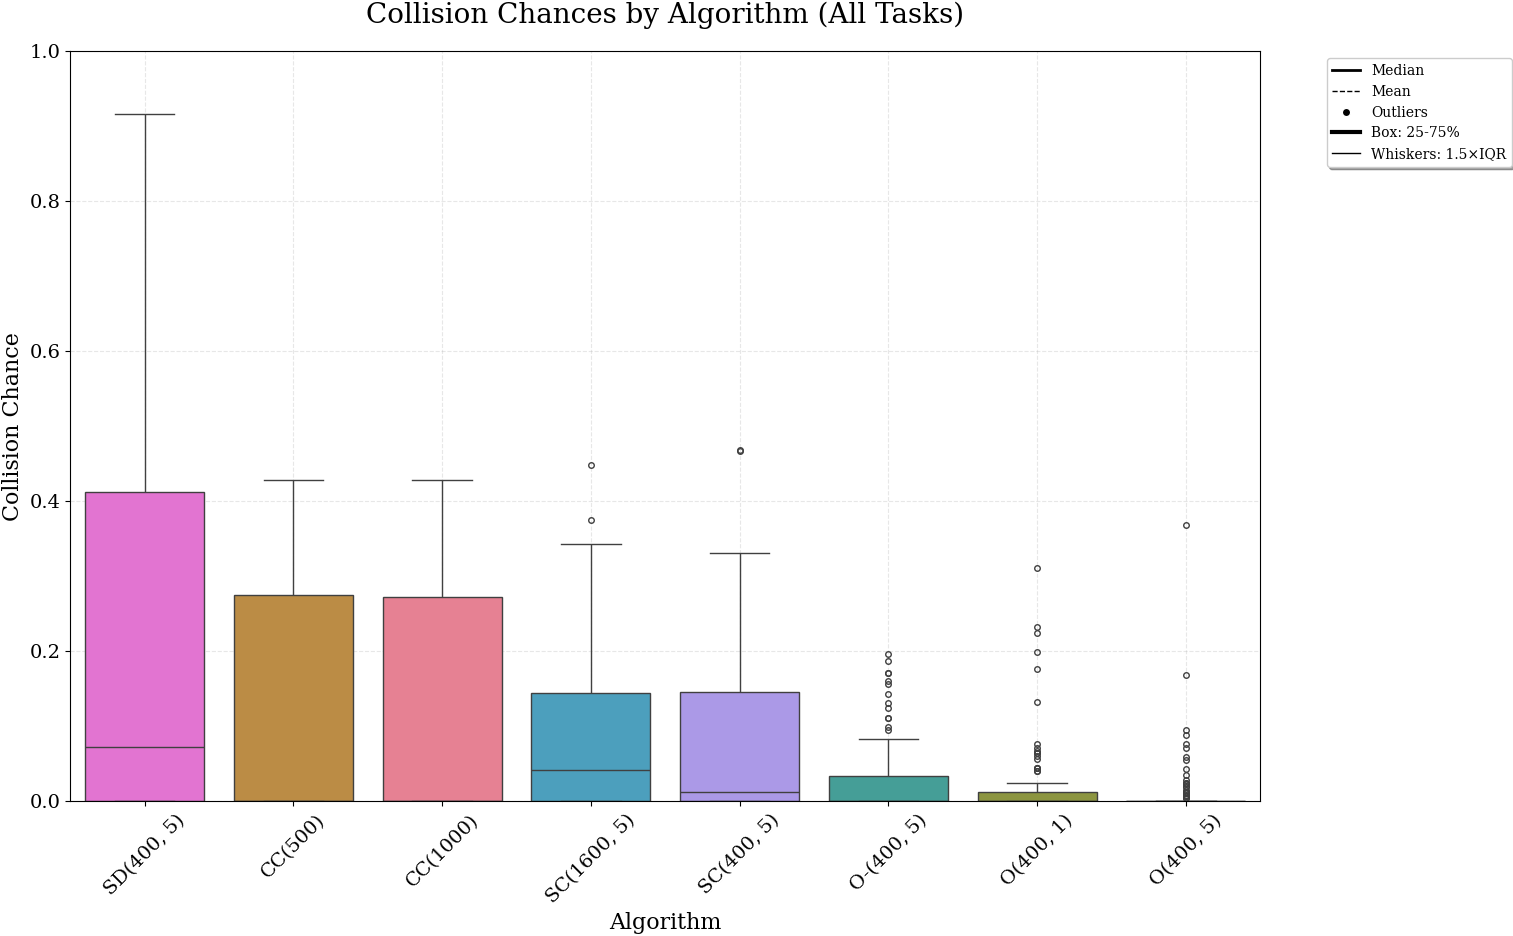

Collision chances over all tasks
             Count  Min    Max    Mean  Std Dev
alg                                            
CC(1000)       120  0.0  0.428  0.0955   0.1456
CC(500)        120  0.0  0.428  0.1000   0.1468
O(400, 1)      120  0.0  0.310  0.0183   0.0494
O(400, 5)      120  0.0  0.368  0.0106   0.0400
O-(400, 5)     120  0.0  0.196  0.0262   0.0467
SC(1600, 5)    120  0.0  0.448  0.0832   0.1007
SC(400, 5)     120  0.0  0.468  0.0815   0.1098
SD(400, 5)     120  0.0  0.916  0.2248   0.2860



,sim_id,alg,col_chance
0,2025-09-08_03:30:27,"O(400, 1)",0.000
1,2025-09-08_04:01:24,"O(400, 1)",0.022
2,2025-09-08_03:27:28,"O(400, 1)",0.000
3,2025-09-08_04:23:09,"O(400, 1)",0.000
4,2025-09-08_04:04:41,"O(400, 1)",0.000
...,...,...,...
955,2025-09-08_22:54:49,CC(500),0.000
956,2025-09-08_22:41:53,CC(500),0.000
957,2025-09-08_22:22:11,CC(500),0.000
958,2025-09-08_23:40:16,CC(500),0.278


In [23]:
analyze_and_plot_collision_chances(df_collisions, by_task=False) # OVER ALL TASKS

# Analyze tasks

In [24]:
if task_analysis:
    overall_df = make_overall_df( # heavy
            df_collisions,
            successfull_parsing,
            valid_sim_dir_paths,
            colfree_only=False,
        )
    

/tmp/ipykernel_3399051/2923877900.py:221: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  overall_df.loc[overall_df['sim_id'] == sim_id, 'cov'] = particle_cfg['mppi']['init_cov']
/tmp/ipykernel_3399051/2923877900.py:220: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1e-08' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  overall_df.loc[overall_df['sim_id'] == sim_id, 'trust'] = particle_cfg['cost']['custom']['arm_base']['dynamic_obs_cost']['wta_trust']


In [25]:
def make_task_success_plots(df, normalize=False, add_subtotal_figure=False, save=False, split_reach=False, colors=None, colormap=None, task_weights=None, df_collisions=None):
    """
    Create task success plots with optional normalization and subtotal figure.
    
    Args:
        df: DataFrame with task success data (overall_df).
            Must have columns: ['alg', 'task_type', 'reached_total', 'placed_total', 'p_err_mean_arms_wsteps']
        normalize: If True, normalize scores to 0-1 range per task
        add_subtotal_figure: If True, add a subtotal figure showing weighted average
        save: If True, save the plot to PDF
        split_reach: If True, split the 'reach' task into subtasks (e.g., 'reach_easy', 'reach_hard')
        colors: Optional color mapping for algorithms. If None, uses default colors.
        colormap: Optional colormap for consistent algorithm colors across all plots.
        task_weights: Optional dict of task weights. If None, uses default weights.
        df_collisions: Optional DataFrame with collision data. If provided, adds collision analysis.
    """
    # --- Style setup ---
    plt.rcParams.update({
        "font.size": 12,
        "axes.labelsize": 12,
        "axes.titlesize": 14,
        "xtick.labelsize": 8,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "figure.figsize": (18, 5),
    })

    def sort_algs(task_df, task_type, score_col, normalized=False):
        """Helper: return sorted list of algorithms based on mean values."""
        if normalized:
            alg_means = {alg: task_df[task_df['alg'] == alg]['normalized_mean'].mean()
                            for alg in algorithms if not task_df[task_df['alg'] == alg].empty}
        else:
            alg_means = {alg: task_df[task_df['alg'] == alg][score_col].mean()
                            for alg in algorithms if not task_df[task_df['alg'] == alg].empty}

        if task_type == 'follow':
            return sorted(alg_means, key=alg_means.get, reverse=True)  # decreasing
        else:
            return sorted(alg_means, key=alg_means.get)  # increasing
    
    def get_score_column(task_type):
        """Helper: get the appropriate score column for each task type."""
        if 'reach' in task_type:
            return 'reached_total'
        elif task_type == 'bin':
            return 'placed_total'
        elif task_type == 'follow':
            return 'p_err_mean_arms_wsteps'
        else:
            return 'reached_total'  # default
    
    def get_ylabel(task_type):
        """Helper: get the appropriate y-label for each task type."""
        if 'reach' in task_type:
            return 'Number of Goals Reached'
        elif task_type == 'bin':
            return 'Number of Items Placed'
        elif task_type == 'follow':
            return 'Position Error (m)'
        else:
            return 'Score'
    
    algorithms = df['alg'].unique()
    
    # Use provided colormap or colors, or default colors
    if colormap is not None:
        # Use provided colormap (should be a dict mapping alg names to colors)
        colors = [colormap.get(alg, plt.cm.tab10(i/len(algorithms))) for i, alg in enumerate(algorithms)]
    elif colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(algorithms)))
    elif isinstance(colors, dict):
        # If colors is a dictionary mapping alg names to colors
        colors = [colors.get(alg, plt.cm.tab10(i/len(algorithms))) for i, alg in enumerate(algorithms)]
    else:
        # If colors is a list, use as is
        colors = colors
    
    # Create a copy to avoid modifying original
    df_work = df.copy()
    
    # Split reach tasks if requested
    if split_reach:
        # Split reach tasks based on task_level
        df_work.loc[(df_work['task_type'] == 'reach') & (df_work['task_level'] <= 5), 'task_type'] = 'reach(easy)'
        df_work.loc[(df_work['task_type'] == 'reach') & (df_work['task_level'] > 5), 'task_type'] = 'reach(hard)'
    
    # Get task types after potential splitting
    task_types = df_work['task_type'].unique()
    n_tasks = len(task_types)
    
    # Determine number of subplots (add collision subplot if df_collisions provided)
    n_subplots = n_tasks + 1  # +1 for overall plot
    if df_collisions is not None:
        n_subplots += 1  # +1 for collision plot
    
    # Create subplots
    fig, axes = plt.subplots(1, n_subplots, figsize=(4*n_subplots, 5))
    
    # Handle case where there's only one task type
    if n_subplots == 1:
        axes = [axes]
    
    # Add overall figure title with sorting information
    fig.suptitle("Algorithm Performance Over Different Tasks (X axis sorted by performance, higher=better)", fontsize=16, y=1.02)
    
    # Create legend elements for boxplots (shared across all boxplot subplots)
    legend_elements = [
        Line2D([0], [0], color='black', lw=2, label='Median'),
        Line2D([0], [0], color='black', lw=1, ls='--', label='Mean'),
        Line2D([0], [0], marker='o', color='w', label='Outliers',
              markerfacecolor='black', markersize=6),
        Line2D([0], [0], color='black', lw=3, label='Box: 25-75%'),
        Line2D([0], [0], color='black', lw=1, label='Whiskers: 1.5×IQR'),
    ]
    
    # Plot each task type in its own subplot
    for i, task_type in enumerate(task_types):
        ax = axes[i]
        task_data = df_work[df_work['task_type'] == task_type]
        
        # Get the appropriate score column and y-label
        score_col = get_score_column(task_type)
        ylabel = get_ylabel(task_type)
        
        # Sort algorithms based on performance
        sorted_algs = sort_algs(task_data, task_type, score_col)
        
        # Create box plot for this task with sorted algorithms
        sns.boxplot(
            data=task_data, 
            x='alg', 
            y=score_col, 
            ax=ax,
            order=sorted_algs,
            palette=colormap
        )
        
        # Calculate actual N for this task (show the range if not all equal)
        n_counts = task_data.groupby('alg').size()
        n_min, n_max = n_counts.min(), n_counts.max()
        if n_min == n_max:
            n_text = f"N={n_min} per algorithm"
        else:
            n_text = f"N={n_min}-{n_max} per algorithm"
        
        # Customize the plot
        ax.set_title(f'{task_type.title()}: {n_text}', fontsize=12)
        ax.set_xlabel('Algorithm', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        
        # Rotate x-axis labels for better readability
        ax.tick_params(axis='x', rotation=45)
        
        # Add legend to the first subplot only
        if i == 0:
            ax.legend(handles=legend_elements, loc='upper left', fontsize=8)
    
    # Create overall subplot with normalized scores
    ax_overall = axes[n_tasks]
    
    # Normalize data for overall comparison
    df_normalized = df_work.copy()
    
    for task_type in task_types:
        task_data = df_normalized[df_normalized['task_type'] == task_type]
        score_col = get_score_column(task_type)
        
        # Normalize to 0-1 range
        min_val = task_data[score_col].min()
        max_val = task_data[score_col].max()
        
        if max_val > min_val:  # Avoid division by zero
            if task_type == 'follow':
                # For follow task, invert the error (1 - normalized_error) so higher=better
                df_normalized.loc[df_normalized['task_type'] == task_type, 'normalized_score'] = 1 - (task_data[score_col] - min_val) / (max_val - min_val)
            else:
                # For reach and bin tasks, higher=better
                df_normalized.loc[df_normalized['task_type'] == task_type, 'normalized_score'] = (task_data[score_col] - min_val) / (max_val - min_val)
        else:
            df_normalized.loc[df_normalized['task_type'] == task_type, 'normalized_score'] = 0.5  # Default to middle if no variation
    
    # Calculate weighted overall scores
    if task_weights is None:
        if split_reach:
            task_weights = {'reach(easy)': 0.25, 'reach(hard)': 0.25, 'bin': 0.25, 'follow': 0.25}
        else:
            task_weights = {'reach': 1/3, 'bin': 1/3, 'follow': 1/3}
    
    # Verify weights sum to 1
    weight_sum = sum(task_weights.values())
    if abs(weight_sum - 1.0) > 1e-6:
        print(f"WARNING: Task weights sum to {weight_sum}, not 1.0")
        # Normalize weights
        task_weights = {k: v/weight_sum for k, v in task_weights.items()}
    
    # Calculate overall scores for each algorithm
    overall_scores = {}
    for alg in algorithms:
        weighted_score = 0
        for task_type, weight in task_weights.items():
            if task_type in task_types:
                task_scores = df_normalized[(df_normalized['task_type'] == task_type) & (df_normalized['alg'] == alg)]['normalized_score']
                if len(task_scores) > 0:
                    weighted_score += weight * task_scores.mean()
        overall_scores[alg] = weighted_score
    
    # Sort algorithms by overall score (HIGHER=BETTER, so reverse=False for left-to-right higher=better)
    sorted_algs_overall = sorted(overall_scores, key=overall_scores.get, reverse=False)
    
    # Create bar plot for overall scores
    y_pos = np.arange(len(sorted_algs_overall))
    scores = [overall_scores[alg] for alg in sorted_algs_overall]
    colors_overall = [colormap.get(alg, plt.cm.tab10(i/len(algorithms))) for alg in sorted_algs_overall]
    
    ax_overall.bar(y_pos, scores, color=colors_overall)
    ax_overall.set_title('Overall Performance\n(Weighted Normalized Score)', fontsize=12)
    ax_overall.set_xlabel('Algorithm', fontsize=12)
    ax_overall.set_ylabel('Normalized Score', fontsize=12)
    ax_overall.set_xticks(y_pos)
    ax_overall.set_xticklabels(sorted_algs_overall, rotation=45)
    ax_overall.set_ylim(0, 1)
    
    # Add weight information to legend (smaller, two rows)
    weight_lines = []
    for task, weight in task_weights.items():
        weight_lines.append(f"{task}: {weight:.2f}")
    
    # Split into two rows if too many tasks
    if len(weight_lines) > 3:
        mid = len(weight_lines) // 2
        weight_text = "Weights:\n" + ", ".join(weight_lines[:mid]) + "\n" + ", ".join(weight_lines[mid:])
    else:
        weight_text = "Weights: " + ", ".join(weight_lines)
    
    ax_overall.text(0.02, 0.98, weight_text, transform=ax_overall.transAxes, 
                   verticalalignment='top', fontsize=7, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Add collision analysis if df_collisions provided
    if df_collisions is not None:
        ax_collision = axes[-1]
        
        # Create a copy of collision data
        df_collision_work = df_collisions.copy()
        
        # Calculate collision chance as min(1, rrc_chance + rre_chance) - same as in analyze_and_plot_collision_chances
        df_collision_work['col_chance'] = df_collision_work.apply(
            lambda row: min(1.0, row['rrc_chance'] + row['rre_chance']), axis=1
        )
        
        # Split reach tasks in collision data if split_reach is True
        if split_reach:
            df_collision_work.loc[(df_collision_work['task_type'] == 'reach') & (df_collision_work['task_level'] <= 5), 'task_type'] = 'reach(easy)'
            df_collision_work.loc[(df_collision_work['task_type'] == 'reach') & (df_collision_work['task_level'] > 5), 'task_type'] = 'reach(hard)'
        
        # Calculate collision scores (1 - collision chance) - higher is better
        df_collision_work['collision_score'] = 1 - df_collision_work['col_chance']
        
        # Calculate weighted collision scores for each algorithm using the same task weights
        collision_scores = {}
        for alg in algorithms:
            weighted_collision_score = 0
            for task_type, weight in task_weights.items():
                if task_type in df_collision_work['task_type'].unique():
                    task_collision_scores = df_collision_work[(df_collision_work['task_type'] == task_type) & (df_collision_work['alg'] == alg)]['collision_score']
                    if len(task_collision_scores) > 0:
                        weighted_collision_score += weight * task_collision_scores.mean()
            collision_scores[alg] = weighted_collision_score
        
        # Calculate combined scores (0.5 * task performance + 0.5 * collision performance)
        combined_scores = {}
        for alg in algorithms:
            combined_scores[alg] = 0.5 * overall_scores[alg] + 0.5 * collision_scores[alg]
        
        # Sort algorithms by combined score (HIGHER=BETTER)
        sorted_algs_combined = sorted(combined_scores, key=combined_scores.get, reverse=False)
        
        # Create bar plot for combined scores
        y_pos_combined = np.arange(len(sorted_algs_combined))
        scores_combined = [combined_scores[alg] for alg in sorted_algs_combined]
        colors_combined = [colormap.get(alg, plt.cm.tab10(i/len(algorithms))) for alg in sorted_algs_combined]
        
        ax_collision.bar(y_pos_combined, scores_combined, color=colors_combined)
        ax_collision.set_title('Overall Performance\nwith Collisions', fontsize=16)
        ax_collision.set_xlabel('Algorithm', fontsize=12)
        ax_collision.set_ylabel('Combined Score', fontsize=12)
        ax_collision.set_xticks(y_pos_combined)
        ax_collision.set_xticklabels(sorted_algs_combined, rotation=45)
        ax_collision.set_ylim(0, 1)
        
        # Add combined score legend
        combined_text = "Combined:\nTasks: 0.5\nCollisions: 0.5"
        ax_collision.text(0.02, 0.98, combined_text, transform=ax_collision.transAxes, 
                         verticalalignment='top', fontsize=7, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    
    # Save if requested
    if save:
        filename = "task_success_plots"
        if split_reach:
            filename += "_split_reach"
        if df_collisions is not None:
            filename += "_with_collisions"
        filename += ".pdf"
        plt.savefig(filename, bbox_inches='tight', dpi=300)
        print(f"Plot saved as {filename}")
    
    plt.show()
    
    return df_work

/tmp/ipykernel_3399051/2037228003.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3399051/2037228003.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3399051/2037228003.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


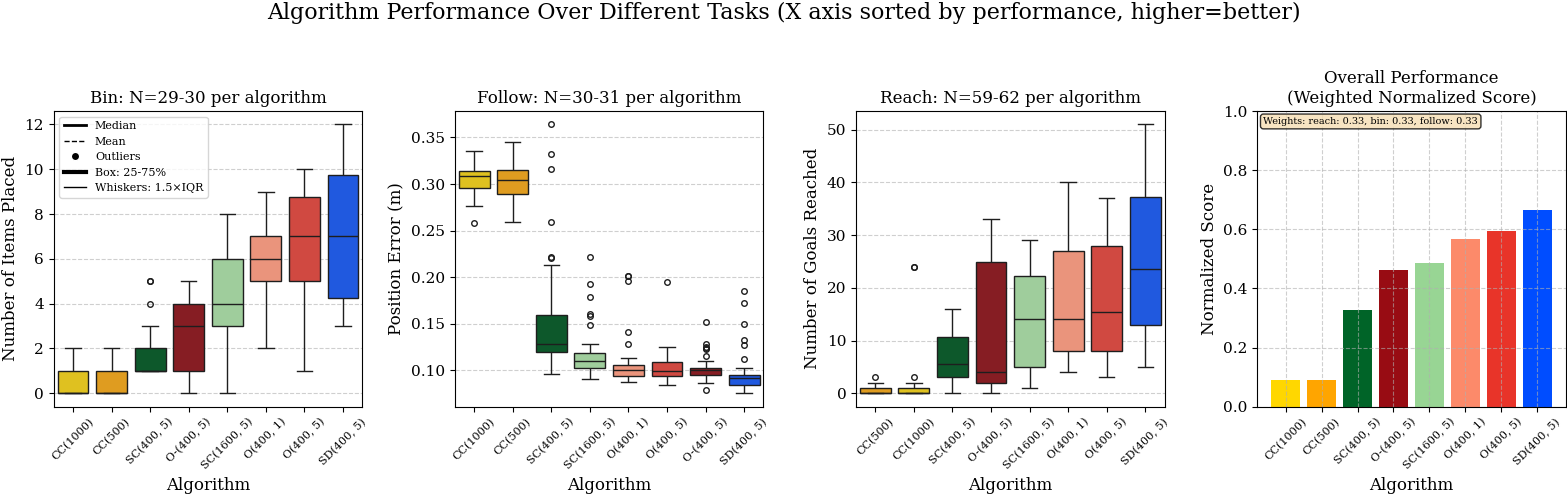

,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,...,changed_total,reached_total,p_err_mean_arms_wsteps,p_err_var_arms_wsteps,task_score_reach,task_score_bin,task_score_follow,safety_score_rrc,safety_score_rec,task_score
0,"O(400, 1)",4,500,bin,2,0,0,0.000,0.000,5,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
1,"O(400, 1)",4,500,bin,4,0,11,0.022,0.000,3,...,NaN,NaN,NaN,NaN,0.0,0.583333,0.000000,0.978,1.000,0.583333
2,"O(400, 1)",4,500,bin,2,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
3,"O(400, 1)",4,500,bin,5,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.666667,0.000000,1.000,1.000,0.666667
4,"O(400, 1)",4,500,bin,4,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,CC(500),4,500,follow,2,0,0,0.000,0.000,5,...,NaN,NaN,0.304553,0.004294,0.0,0.083333,0.205842,1.000,1.000,0.289175
956,CC(500),4,500,follow,2,0,0,0.000,0.000,2,...,NaN,NaN,0.297082,0.006397,0.0,0.000000,0.231740,1.000,1.000,0.231740
957,CC(500),4,500,follow,1,0,0,0.000,0.000,3,...,NaN,NaN,0.310030,0.004109,0.0,0.000000,0.186856,1.000,1.000,0.186856
958,CC(500),4,500,follow,4,139,0,0.000,0.278,3,...,NaN,NaN,0.307996,0.003918,0.0,0.000000,0.193907,1.000,0.722,0.193907


In [26]:
make_task_success_plots(overall_df, normalize=False, add_subtotal_figure=True,colormap=alg_colors)

/tmp/ipykernel_3399051/2037228003.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3399051/2037228003.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


/tmp/ipykernel_3399051/2037228003.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


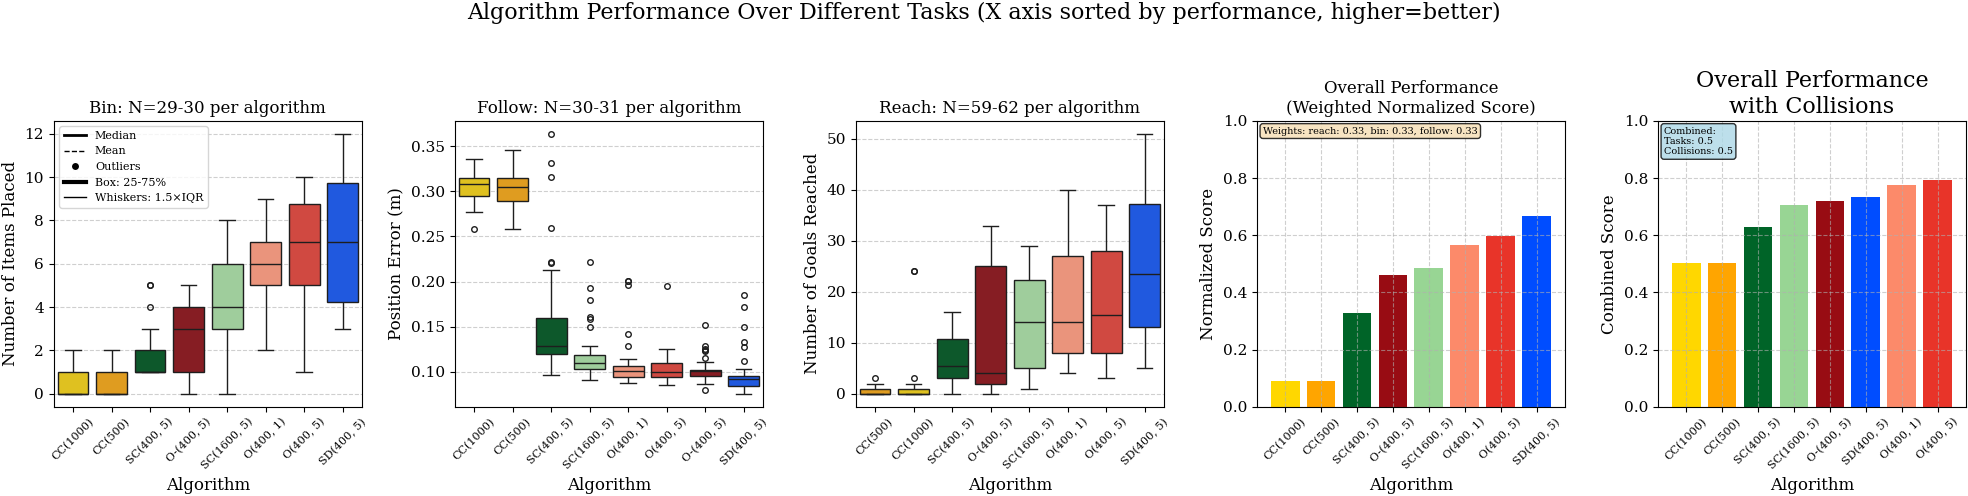

,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,...,changed_total,reached_total,p_err_mean_arms_wsteps,p_err_var_arms_wsteps,task_score_reach,task_score_bin,task_score_follow,safety_score_rrc,safety_score_rec,task_score
0,"O(400, 1)",4,500,bin,2,0,0,0.000,0.000,5,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
1,"O(400, 1)",4,500,bin,4,0,11,0.022,0.000,3,...,NaN,NaN,NaN,NaN,0.0,0.583333,0.000000,0.978,1.000,0.583333
2,"O(400, 1)",4,500,bin,2,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
3,"O(400, 1)",4,500,bin,5,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.666667,0.000000,1.000,1.000,0.666667
4,"O(400, 1)",4,500,bin,4,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,CC(500),4,500,follow,2,0,0,0.000,0.000,5,...,NaN,NaN,0.304553,0.004294,0.0,0.083333,0.205842,1.000,1.000,0.289175
956,CC(500),4,500,follow,2,0,0,0.000,0.000,2,...,NaN,NaN,0.297082,0.006397,0.0,0.000000,0.231740,1.000,1.000,0.231740
957,CC(500),4,500,follow,1,0,0,0.000,0.000,3,...,NaN,NaN,0.310030,0.004109,0.0,0.000000,0.186856,1.000,1.000,0.186856
958,CC(500),4,500,follow,4,139,0,0.000,0.278,3,...,NaN,NaN,0.307996,0.003918,0.0,0.000000,0.193907,1.000,0.722,0.193907


In [27]:
make_task_success_plots(overall_df, normalize=False, add_subtotal_figure=True,colormap=alg_colors,split_reach=False,df_collisions=df_collisions)

/tmp/ipykernel_3399051/2037228003.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3399051/2037228003.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3399051/2037228003.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3399051/2037228003.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


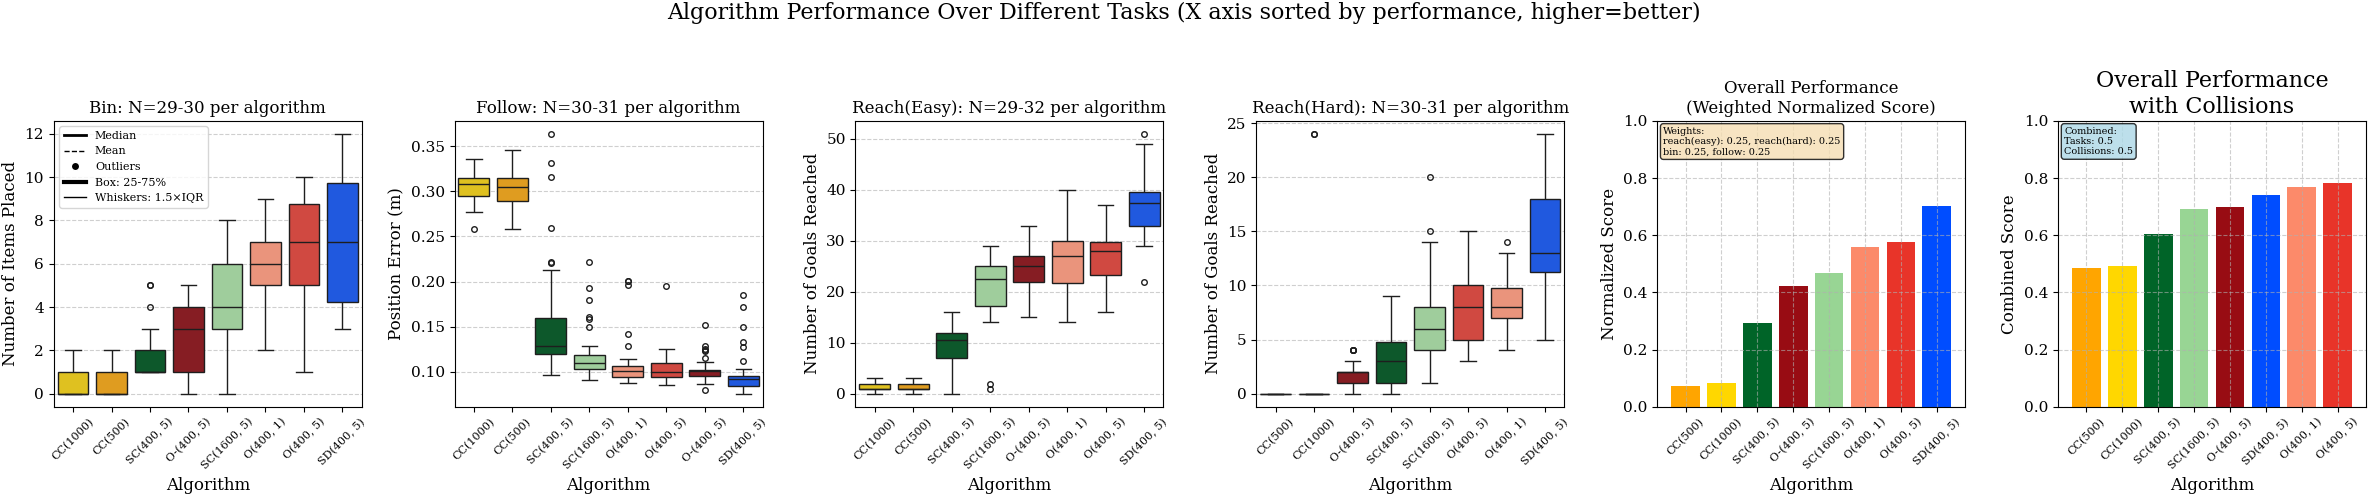

,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,...,changed_total,reached_total,p_err_mean_arms_wsteps,p_err_var_arms_wsteps,task_score_reach,task_score_bin,task_score_follow,safety_score_rrc,safety_score_rec,task_score
0,"O(400, 1)",4,500,bin,2,0,0,0.000,0.000,5,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
1,"O(400, 1)",4,500,bin,4,0,11,0.022,0.000,3,...,NaN,NaN,NaN,NaN,0.0,0.583333,0.000000,0.978,1.000,0.583333
2,"O(400, 1)",4,500,bin,2,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
3,"O(400, 1)",4,500,bin,5,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.666667,0.000000,1.000,1.000,0.666667
4,"O(400, 1)",4,500,bin,4,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,CC(500),4,500,follow,2,0,0,0.000,0.000,5,...,NaN,NaN,0.304553,0.004294,0.0,0.083333,0.205842,1.000,1.000,0.289175
956,CC(500),4,500,follow,2,0,0,0.000,0.000,2,...,NaN,NaN,0.297082,0.006397,0.0,0.000000,0.231740,1.000,1.000,0.231740
957,CC(500),4,500,follow,1,0,0,0.000,0.000,3,...,NaN,NaN,0.310030,0.004109,0.0,0.000000,0.186856,1.000,1.000,0.186856
958,CC(500),4,500,follow,4,139,0,0.000,0.278,3,...,NaN,NaN,0.307996,0.003918,0.0,0.000000,0.193907,1.000,0.722,0.193907


In [28]:
make_task_success_plots(overall_df, normalize=False, add_subtotal_figure=True,colormap=alg_colors,split_reach=True,df_collisions=df_collisions)

In [29]:
def debug_data_structure(df):
    """Debug function to check data structure and counts"""
    print("=== DATA STRUCTURE DEBUG ===")
    print(f"Total rows: {len(df)}")
    print(f"Unique algorithms: {df['alg'].unique()}")
    print(f"Unique task types: {df['task_type'].unique()}")
    print("\n=== COUNTS BY ALGORITHM AND TASK TYPE ===")
    
    # Check counts for each algorithm-task combination
    for alg in df['alg'].unique():
        print(f"\nAlgorithm: {alg}")
        for task_type in df['task_type'].unique():
            count = len(df[(df['alg'] == alg) & (df['task_type'] == task_type)])
            print(f"  {task_type}: {count} trials")
    
    print("\n=== REACH TASK LEVELS ===")
    reach_data = df[df['task_type'] == 'reach']
    if 'task_level' in reach_data.columns:
        print("Task levels in reach data:")
        print(reach_data['task_level'].value_counts().sort_index())
        print(f"Easy (<=5): {len(reach_data[reach_data['task_level'] <= 5])}")
        print(f"Hard (>5): {len(reach_data[reach_data['task_level'] > 5])}")
    else:
        print("No task_level column found!")
    
    return df

debug_data_structure(overall_df)

=== DATA STRUCTURE DEBUG ===
Total rows: 960
Unique algorithms: ['O(400, 1)' 'O(400, 5)' 'O-(400, 5)' 'SC(1600, 5)' 'SC(400, 5)' 'CC(500)'
 'SD(400, 5)' 'CC(1000)']
Unique task types: ['bin' 'follow' 'reach']

=== COUNTS BY ALGORITHM AND TASK TYPE ===

Algorithm: O(400, 1)
  bin: 30 trials
  follow: 30 trials
  reach: 60 trials

Algorithm: O(400, 5)
  bin: 30 trials
  follow: 30 trials
  reach: 60 trials

Algorithm: O-(400, 5)
  bin: 29 trials
  follow: 31 trials
  reach: 59 trials

Algorithm: SC(1600, 5)
  bin: 29 trials
  follow: 30 trials
  reach: 60 trials

Algorithm: SC(400, 5)
  bin: 29 trials
  follow: 30 trials
  reach: 62 trials

Algorithm: CC(500)
  bin: 29 trials
  follow: 31 trials
  reach: 60 trials

Algorithm: SD(400, 5)
  bin: 30 trials
  follow: 30 trials
  reach: 60 trials

Algorithm: CC(1000)
  bin: 30 trials
  follow: 30 trials
  reach: 61 trials

=== REACH TASK LEVELS ===
Task levels in reach data:
task_level
1     49
2     48
3     48
4     48
5     48
6     48
7  

,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,...,changed_total,reached_total,p_err_mean_arms_wsteps,p_err_var_arms_wsteps,task_score_reach,task_score_bin,task_score_follow,safety_score_rrc,safety_score_rec,task_score
0,"O(400, 1)",4,500,bin,2,0,0,0.000,0.000,5,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
1,"O(400, 1)",4,500,bin,4,0,11,0.022,0.000,3,...,NaN,NaN,NaN,NaN,0.0,0.583333,0.000000,0.978,1.000,0.583333
2,"O(400, 1)",4,500,bin,2,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
3,"O(400, 1)",4,500,bin,5,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.666667,0.000000,1.000,1.000,0.666667
4,"O(400, 1)",4,500,bin,4,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,CC(500),4,500,follow,2,0,0,0.000,0.000,5,...,NaN,NaN,0.304553,0.004294,0.0,0.083333,0.205842,1.000,1.000,0.289175
956,CC(500),4,500,follow,2,0,0,0.000,0.000,2,...,NaN,NaN,0.297082,0.006397,0.0,0.000000,0.231740,1.000,1.000,0.231740
957,CC(500),4,500,follow,1,0,0,0.000,0.000,3,...,NaN,NaN,0.310030,0.004109,0.0,0.000000,0.186856,1.000,1.000,0.186856
958,CC(500),4,500,follow,4,139,0,0.000,0.278,3,...,NaN,NaN,0.307996,0.003918,0.0,0.000000,0.193907,1.000,0.722,0.193907


In [61]:
def combined_task_collision_plot(df, df_collisions, split_reach=False, colormap=None, save=False):
    """
    Create combined plots showing task performance and collision chances side by side.
    
    Args:
        df: DataFrame with task success data (overall_df).
        df_collisions: DataFrame with collision data.
        split_reach: If True, split the 'reach' task into subtasks (e.g., 'reach_easy', 'reach_hard')
        colormap: Optional colormap for consistent algorithm colors across all plots.
        save: If True, save the plot to PDF
    """
    # --- Style setup ---
    plt.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 15,
        "axes.titlesize": 15,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.figsize": (20, 7),  # Increased height from 6 to 7
    })

    def get_score_column(task_type):
        """Helper: get the appropriate score column for each task type."""
        if 'reach' in task_type:
            return 'reached_total'
        elif task_type == 'bin':
            return 'placed_total'
        elif task_type == 'follow':
            return 'p_err_mean_arms_wsteps'
        else:
            return 'reached_total'  # default
    
    def get_ylabel(task_type):
        """Helper: get the appropriate y-label for each task type."""
        if 'reach' in task_type:
            return 'Number of Goals Reached'
        elif task_type == 'bin':
            return 'Number of Items Placed'
        elif task_type == 'follow':
            return 'Position Error (m)'
        else:
            return 'Score'
    
    algorithms = df['alg'].unique()
     
    
    # Create a copy to avoid modifying original
    df_work = df.copy()
    df_collision_work = df_collisions.copy()
    
    # Split reach tasks if requested
    if split_reach:
        # Split reach tasks based on task_level
        df_work.loc[(df_work['task_type'] == 'reach') & (df_work['task_level'] <= 5), 'task_type'] = 'reach(easy)'
        df_work.loc[(df_work['task_type'] == 'reach') & (df_work['task_level'] > 5), 'task_type'] = 'reach(hard)'
        
        df_collision_work.loc[(df_collision_work['task_type'] == 'reach') & (df_collision_work['task_level'] <= 5), 'task_type'] = 'reach(easy)'
        df_collision_work.loc[(df_collision_work['task_type'] == 'reach') & (df_collision_work['task_level'] > 5), 'task_type'] = 'reach(hard)'
    
    # Calculate collision chance as min(1, rrc_chance + rre_chance)
    df_collision_work['col_chance'] = df_collision_work.apply(
        lambda row: min(1.0, row['rrc_chance'] + row['rre_chance']), axis=1
    )
    
    # Get task types after potential splitting
    task_types = df_work['task_type'].unique()
    task_types = sorted(task_types)
    n_tasks = len(task_types)
    
    # Create subplots - one for each task type + overall (n_tasks + 1 subplots total)
    fig, axes = plt.subplots(1, n_tasks + 1, figsize=(6*(n_tasks + 1), 7),sharey=True)  # Increased height
    
    # Handle case where there's only one task type
    if n_tasks == 1:
        axes = [axes[0], axes[1]]
    
    # Add overall figure title with formula - INCREASED BY 20%
    fig.suptitle(
        r"Task Scores & Collision Chance (boxes are sorted by combined score △)",
        fontsize=21, x=0.55, y=0.99, ha="center"
    )

    # Create legend elements for boxplots (shared across all boxplot subplots)
    legend_elements = [
        Line2D([0], [0], color='black', lw=2, label='Median'),
        Line2D([0], [0], color='black', lw=1, ls='--', label='Mean'),
        Line2D([0], [0], marker='o', color='w', label='Outliers',
              markerfacecolor='black', markersize=6),
        Line2D([0], [0], color='black', lw=3, label='Box: 25-75%'),
        Line2D([0], [0], color='black', lw=1, label='Whiskers: 1.5×IQR'),
    ]
    
    # Create shared legend elements for task performance vs collision with proper visual representation
    from matplotlib.patches import Patch
    shared_legend_elements = [
        Patch(facecolor='gray', alpha=0.7, label='Task Score(higher=better)'),
        Patch(facecolor='gray', alpha=0.5, hatch='///', label='Collision Chance(lower=better)'),
        Line2D([0], [0], marker='^', color='red', lw=0, markersize=8, label='Combined Score(△) (higher=better)'),
    ]
    title_map = {
            'reach(easy)':'Reaching(Easy)',
            'reach(hard)':'Reaching(Hard)',
            'bin': 'Bin Loading',
            'follow':'Following'
        }
    
    # Plot each task type
    alg_names_rotation = 30
    alg_names_fontsize = 14
    subplot_title_size=17
    candle_width=0.4
    for i, task_type in enumerate(task_types):
        ax = axes[i]
        task_data = df_work[df_work['task_type'] == task_type]
        collision_data = df_collision_work[df_collision_work['task_type'] == task_type]
        
        # Get the appropriate score column and y-label
        score_col = get_score_column(task_type)
        ylabel = get_ylabel(task_type)
        
        # Normalize task scores to 0-1 range
        min_val = task_data[score_col].min()
        max_val = task_data[score_col].max()
        
        if max_val > min_val:  # Avoid division by zero
            if task_type == 'follow':
                # For follow task, invert the error (1 - normalized_error) so higher=better
                task_data = task_data.copy()
                task_data['normalized_score'] = 1 - (task_data[score_col] - min_val) / (max_val - min_val)
            else:
                # For reach and bin tasks, higher=better
                task_data = task_data.copy()
                task_data['normalized_score'] = (task_data[score_col] - min_val) / (max_val - min_val)
        else:
            task_data = task_data.copy()
            task_data['normalized_score'] = 0.5  # Default to middle if no variation
        
        # Calculate combined scores for sorting: (task_score + (1 - collision_score)) / 2
        combined_scores = {}
        for alg in algorithms:
            # Task performance (a1)
            alg_task_scores = task_data[task_data['alg'] == alg]['normalized_score'].values
            if len(alg_task_scores) > 0:
                a1 = np.mean(alg_task_scores)
            else:
                a1 = 0.5
            
            # Collision safety (a2 = 1 - collision_chance)
            alg_collision_scores = collision_data[collision_data['alg'] == alg]['col_chance'].values
            if len(alg_collision_scores) > 0:
                a2 = 1 - np.mean(alg_collision_scores)  # 1 - collision chance (higher is better)
            else:
                a2 = 0.5
            
            combined_scores[alg] = (a1 + a2) / 2
        
        # Sort algorithms by combined score in INCREASING order (higher scores on the right)
        sorted_algs = sorted(combined_scores, key=combined_scores.get, reverse=False)
        
        # Create combined plot with task performance and collision chances
        # Task performance (left half of each algorithm)
        task_positions = np.arange(len(sorted_algs)) - 0.2
        collision_positions = np.arange(len(sorted_algs)) + 0.2
        
        # Plot task performance boxes
        task_boxes = ax.boxplot(
            [task_data[task_data['alg'] == alg]['normalized_score'].values for alg in sorted_algs],
            positions=task_positions,
            widths=candle_width,
            patch_artist=True,
            tick_labels=sorted_algs,
            medianprops=dict(linestyle='-', color='black', linewidth=2)  # Only median, no showmeans
        )
        
        # Color task performance boxes
        for j, (box, alg) in enumerate(zip(task_boxes['boxes'], sorted_algs)):
            if colormap is not None:
                box.set_facecolor(colormap.get(alg, plt.cm.tab10(j/len(algorithms))))
            else:
                box.set_facecolor(plt.cm.tab10(j/len(algorithms)))
            box.set_alpha(0.7)
        
        # Plot collision chances (right half of each algorithm) with dashed pattern
        collision_boxes = ax.boxplot(
            [collision_data[collision_data['alg'] == alg]['col_chance'].values for alg in sorted_algs],
            positions=collision_positions,
            widths=candle_width,
            patch_artist=True,
            tick_labels=[''] * len(sorted_algs),
            medianprops=dict(linestyle='-', color='black', linewidth=2)  # Only median, no showmeans
        )
        
        # Color collision boxes with dashed pattern
        for j, (box, alg) in enumerate(zip(collision_boxes['boxes'], sorted_algs)):
            if colormap is not None:
                box.set_facecolor(colormap.get(alg, plt.cm.tab10(j/len(algorithms))))
            else:
                box.set_facecolor(plt.cm.tab10(j/len(algorithms)))
            box.set_alpha(0.5)
            # Add dashed pattern
            box.set_hatch('///')
        
        # MANUALLY ADD MEAN LINES as horizontal dashed lines
        for j, alg in enumerate(sorted_algs):
            # Task performance mean line
            alg_task_scores = task_data[task_data['alg'] == alg]['normalized_score'].values
            if len(alg_task_scores) > 0:
                task_mean = np.mean(alg_task_scores)
                ax.plot([task_positions[j] - candle_width/2, task_positions[j] + candle_width/2], 
                       [task_mean, task_mean], 'k--', linewidth=1, alpha=0.7)
            
            # Collision chance mean line
            alg_collision_scores = collision_data[collision_data['alg'] == alg]['col_chance'].values
            if len(alg_collision_scores) > 0:
                collision_mean = np.mean(alg_collision_scores)
                ax.plot([collision_positions[j] - candle_width/2, collision_positions[j] + candle_width/2], 
                       [collision_mean, collision_mean], 'k--', linewidth=1, alpha=0.7)
        
        # Add TRIANGLE markers for combined scores
        triangle_positions = np.arange(len(sorted_algs))
        triangle_values = [combined_scores[alg] for alg in sorted_algs]
        triangle_colors = [colormap.get(alg, plt.cm.tab10(j/len(algorithms))) for j, alg in enumerate(sorted_algs)]
        
        # Add horizontal lines connecting the triangles to the boxes
        for j, (pos, val) in enumerate(zip(triangle_positions, triangle_values)):
            ax.plot([pos - 0.3, pos + 0.3], [val, val], 'k-', linewidth=1, alpha=0.7)
            # Add triangle at the center
            ax.scatter(pos, val, marker='^', s=80, c=triangle_colors[j],
                      edgecolors='black', linewidth=1, zorder=10)
        
        # Calculate actual N for this task
        n_counts = task_data.groupby('alg').size()
        n_min, n_max = n_counts.min(), n_counts.max()
        n_text = f"N={30} per algorithm"
        
        # Customize the plot
        ax.set_title(f'{title_map[task_type]}: {n_text}', fontsize=subplot_title_size)
        ax.set_xlabel("", fontsize=12)  # Remove individual "Algorithm" labels
        
        ax.set_xticks(np.arange(len(sorted_algs)))
        ax.set_xticklabels(sorted_algs, rotation=alg_names_rotation, fontsize=alg_names_fontsize)
        ax.set_ylim(0, 1.0)
        
        # Add grid
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Add boxplot legend to the first subplot only
        if i == 0:
            ax.legend(handles=legend_elements, loc='upper left', fontsize=13)
    
    # Create overall subplot
    ax_overall = axes[-1]
    
    # Calculate task weights
    if split_reach:
        task_weights = {'reach(easy)': 0.25, 'reach(hard)': 0.25, 'bin': 0.25, 'follow': 0.25}
    else:
        task_weights = {'reach': 1/3, 'bin': 1/3, 'follow': 1/3}
    
    # Calculate weighted overall task performance for each algorithm
    overall_task_scores = {}
    for alg in algorithms:
        weighted_score = 0
        for task_type, weight in task_weights.items():
            if task_type in task_types:
                task_data = df_work[df_work['task_type'] == task_type]
                score_col = get_score_column(task_type)
                
                # Normalize to 0-1 range
                min_val = task_data[score_col].min()
                max_val = task_data[score_col].max()
                
                if max_val > min_val:
                    if task_type == 'follow':
                        normalized_score = 1 - (task_data[task_data['alg'] == alg][score_col] - min_val) / (max_val - min_val)
                    else:
                        normalized_score = (task_data[task_data['alg'] == alg][score_col] - min_val) / (max_val - min_val)
                else:
                    normalized_score = np.array([0.5])
                
                if len(normalized_score) > 0:
                    weighted_score += weight * normalized_score.mean()
        
        overall_task_scores[alg] = weighted_score
    
    # Calculate overall collision chances for each algorithm
    overall_collision_scores = {}
    for alg in algorithms:
        alg_collisions = df_collision_work[df_collision_work['alg'] == alg]['col_chance'].values
        if len(alg_collisions) > 0:
            overall_collision_scores[alg] = np.mean(alg_collisions)
        else:
            overall_collision_scores[alg] = 0.5
    
    # Calculate combined scores: (task_score + (1 - collision_score)) / 2
    combined_scores = {}
    for alg in algorithms:
        a1 = overall_task_scores[alg]  # Task performance
        a2 = 1 - overall_collision_scores[alg]  # 1 - collision chance (higher is better)
        combined_scores[alg] = (a1 + a2) / 2
    
    # Sort algorithms by combined score in INCREASING order (higher scores on the right)
    sorted_algs_overall = sorted(combined_scores, key=combined_scores.get, reverse=False)
    
    # Create side-by-side bar plots
    x_pos = np.arange(len(sorted_algs_overall))
    task_scores = [overall_task_scores[alg] for alg in sorted_algs_overall]
    collision_scores = [overall_collision_scores[alg] for alg in sorted_algs_overall]
    colors_overall = [colormap.get(alg, plt.cm.tab10(j/len(algorithms))) for alg in sorted_algs_overall]
    
    # Plot task performance bars (left)
    task_bars = ax_overall.bar(x_pos - 0.2, task_scores, 0.4, 
                              color=colors_overall, alpha=0.7, label='Task Score')
    
    # Plot collision chance bars (right)
    collision_bars = ax_overall.bar(x_pos + 0.2, collision_scores, 0.4, 
                                   color=colors_overall, alpha=0.5, 
                                   hatch='///', label='Collision Chance')
    
    # MANUALLY ADD MEAN LINES for overall bars
    for j, (pos, task_score, collision_score) in enumerate(zip(x_pos, task_scores, collision_scores)):
        # Task performance mean line
        ax_overall.plot([pos - 0.2 - 0.2, pos - 0.2 + 0.2], [task_score, task_score], 'k--', linewidth=1, alpha=0.7)
        # Collision chance mean line
        ax_overall.plot([pos + 0.2 - 0.2, pos + 0.2 + 0.2], [collision_score, collision_score], 'k--', linewidth=1, alpha=0.7)
    
    # Add TRIANGLE markers for overall combined scores
    triangle_values_overall = [combined_scores[alg] for alg in sorted_algs_overall]
    
    # Add horizontal lines for overall combined scores
    for j, (pos, val) in enumerate(zip(x_pos, triangle_values_overall)):
        ax_overall.plot([pos - 0.3, pos + 0.3], [val, val], 'k-', linewidth=1, alpha=0.7)
        # Add triangle at the center
        ax_overall.scatter(pos, val, marker='^', s=80, c=colors_overall[j],
                          edgecolors='black', linewidth=1, zorder=10)
    
    # Customize overall plot
    ax_overall.set_title('Overall: N=120 per algorithm', fontsize=subplot_title_size)
    ax_overall.set_xlabel("", fontsize=12)  # Remove individual "Algorithm" label
    ax_overall.set_ylabel("", fontsize=20)  # Remove y-label
    ax_overall.tick_params(axis='y', left=True, labelleft=False)  # Keep ticks but no labels
    ax_overall.set_xticks(x_pos)
    ax_overall.set_xticklabels(sorted_algs_overall, rotation=alg_names_rotation, fontsize=alg_names_fontsize)
    ax_overall.set_ylim(0, 1.0)
    ax_overall.grid(True, alpha=0.3, linestyle='--')
    
    # Add shared legend for Task Performance vs Collision Chance at the top of the figure
    fig.legend(handles=shared_legend_elements, loc='upper center', 
              bbox_to_anchor=(0.55, 0.955), ncol=3, fontsize=16,
              frameon=True, fancybox=True, shadow=True)
    
    # Add unified "Algorithm" x-axis title centered below all subplots
    fig.text(0.5, 0.005, 'Algorithm', ha='center', va='bottom', fontsize=17)
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.subplots_adjust(left=0.15, top=0.825, right=0.95, wspace=0.015)
    
    # Save if requested
    if save:
        filename = "combined_task_collision_plot"
        if split_reach:
            filename += "_split_reach"
        filename += ".pdf"
        plt.savefig(filename, bbox_inches='tight', dpi=300)
        print(f"Plot saved as {filename}")
    
    plt.show()
    
    return df_work

/tmp/ipykernel_3399051/3984703372.py:217: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(pos, val, marker='^', s=80, c=triangle_colors[j],  # KEEP AS TRIANGLE
/tmp/ipykernel_3399051/3984703372.py:217: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(pos, val, marker='^', s=80, c=triangle_colors[j],  # KEEP AS TRIANGLE
/tmp/ipykernel_3399051/3984703372.py:217: UserWarning: *c* argument looks like a single nu

Plot saved as combined_task_collision_plot_split_reach.pdf


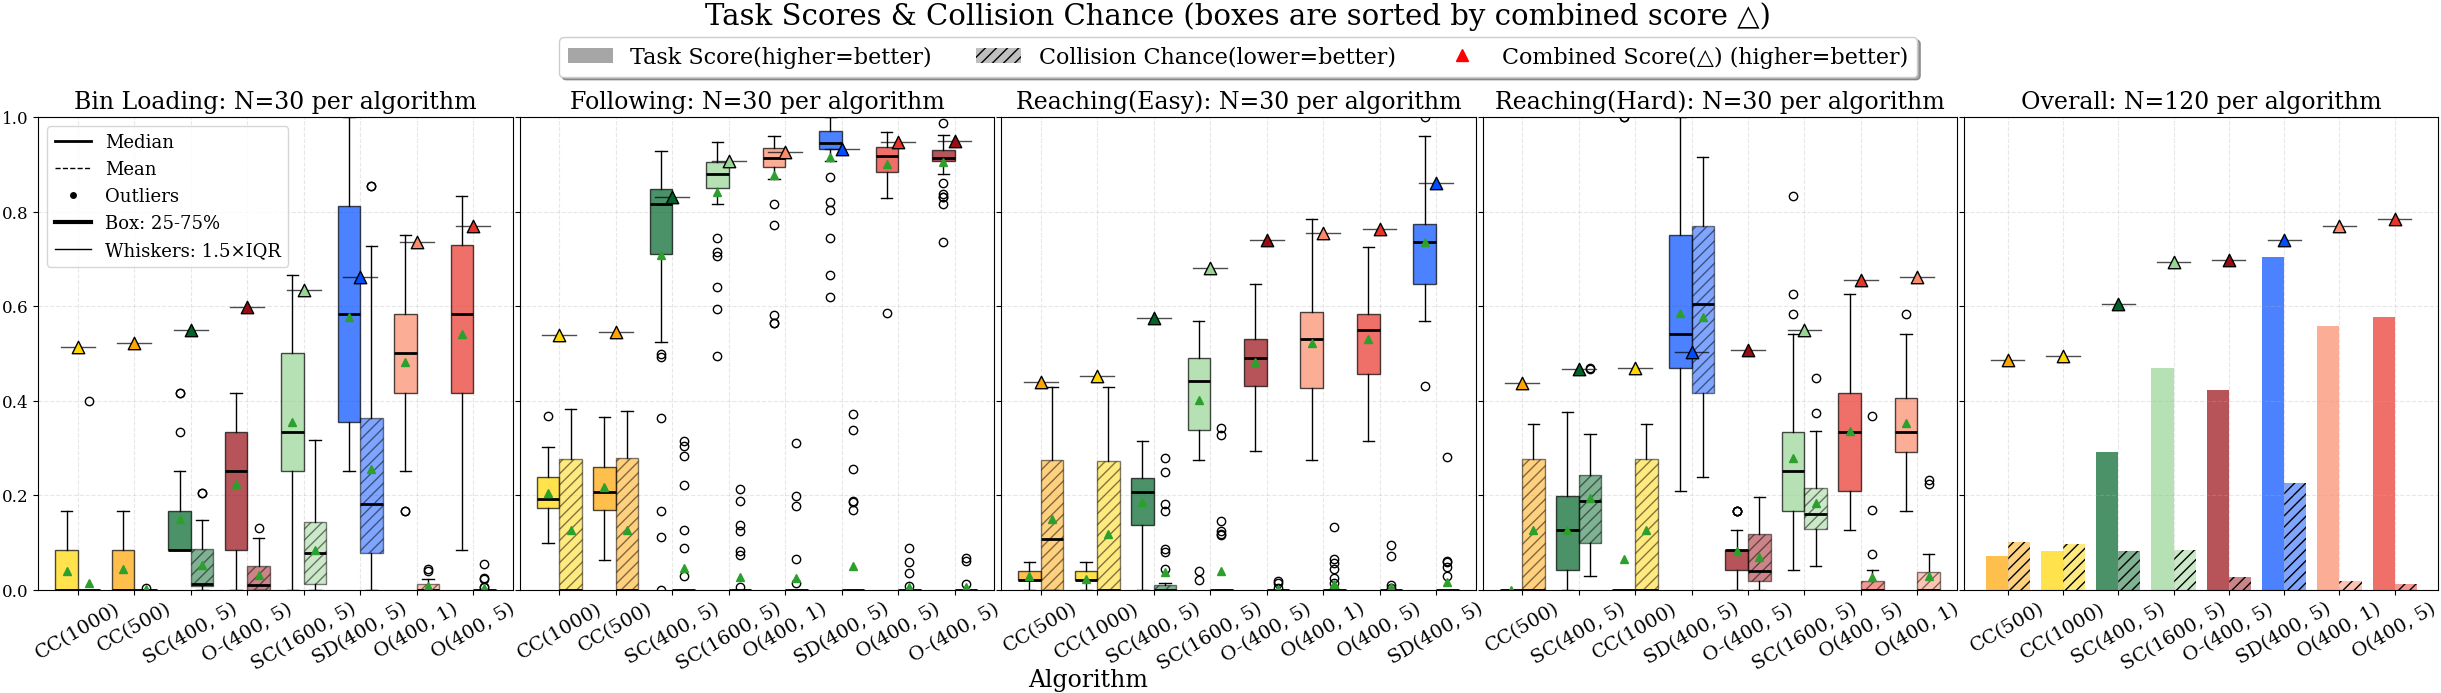

,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,...,changed_total,reached_total,p_err_mean_arms_wsteps,p_err_var_arms_wsteps,task_score_reach,task_score_bin,task_score_follow,safety_score_rrc,safety_score_rec,task_score
0,"O(400, 1)",4,500,bin,2,0,0,0.000,0.000,5,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
1,"O(400, 1)",4,500,bin,4,0,11,0.022,0.000,3,...,NaN,NaN,NaN,NaN,0.0,0.583333,0.000000,0.978,1.000,0.583333
2,"O(400, 1)",4,500,bin,2,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
3,"O(400, 1)",4,500,bin,5,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.666667,0.000000,1.000,1.000,0.666667
4,"O(400, 1)",4,500,bin,4,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,CC(500),4,500,follow,2,0,0,0.000,0.000,5,...,NaN,NaN,0.304553,0.004294,0.0,0.083333,0.205842,1.000,1.000,0.289175
956,CC(500),4,500,follow,2,0,0,0.000,0.000,2,...,NaN,NaN,0.297082,0.006397,0.0,0.000000,0.231740,1.000,1.000,0.231740
957,CC(500),4,500,follow,1,0,0,0.000,0.000,3,...,NaN,NaN,0.310030,0.004109,0.0,0.000000,0.186856,1.000,1.000,0.186856
958,CC(500),4,500,follow,4,139,0,0.000,0.278,3,...,NaN,NaN,0.307996,0.003918,0.0,0.000000,0.193907,1.000,0.722,0.193907


In [60]:
combined_task_collision_plot(overall_df, df_collisions, split_reach=True, colormap=alg_colors, save=True)


/tmp/ipykernel_3399051/3923913303.py:229: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(pos, val, marker='^', s=80, c=triangle_colors[j],
/tmp/ipykernel_3399051/3923913303.py:229: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(pos, val, marker='^', s=80, c=triangle_colors[j],
/tmp/ipykernel_3399051/3923913303.py:229: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should

Plot saved as combined_task_collision_plot_split_reach.pdf


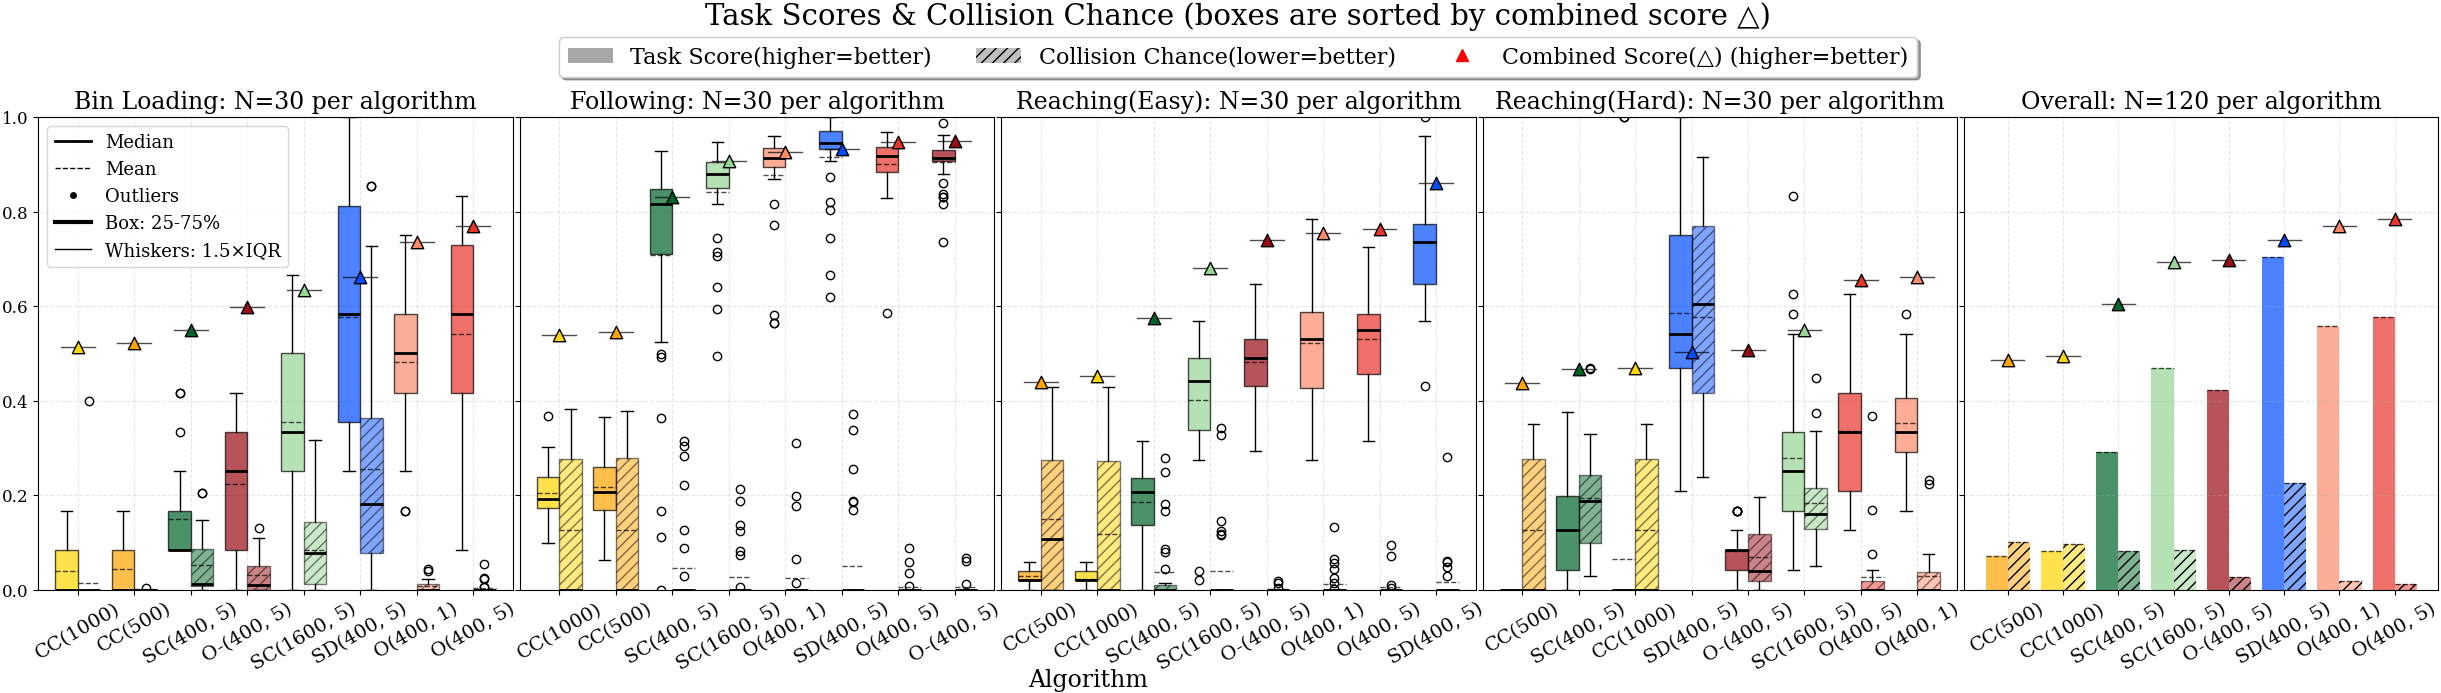

,alg,n_arms,wstep_total,task_type,task_level,rre_n,rrc_n,rrc_chance,rre_chance,task_seed,...,changed_total,reached_total,p_err_mean_arms_wsteps,p_err_var_arms_wsteps,task_score_reach,task_score_bin,task_score_follow,safety_score_rrc,safety_score_rec,task_score
0,"O(400, 1)",4,500,bin,2,0,0,0.000,0.000,5,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
1,"O(400, 1)",4,500,bin,4,0,11,0.022,0.000,3,...,NaN,NaN,NaN,NaN,0.0,0.583333,0.000000,0.978,1.000,0.583333
2,"O(400, 1)",4,500,bin,2,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
3,"O(400, 1)",4,500,bin,5,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.666667,0.000000,1.000,1.000,0.666667
4,"O(400, 1)",4,500,bin,4,0,0,0.000,0.000,4,...,NaN,NaN,NaN,NaN,0.0,0.500000,0.000000,1.000,1.000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,CC(500),4,500,follow,2,0,0,0.000,0.000,5,...,NaN,NaN,0.304553,0.004294,0.0,0.083333,0.205842,1.000,1.000,0.289175
956,CC(500),4,500,follow,2,0,0,0.000,0.000,2,...,NaN,NaN,0.297082,0.006397,0.0,0.000000,0.231740,1.000,1.000,0.231740
957,CC(500),4,500,follow,1,0,0,0.000,0.000,3,...,NaN,NaN,0.310030,0.004109,0.0,0.000000,0.186856,1.000,1.000,0.186856
958,CC(500),4,500,follow,4,139,0,0.000,0.278,3,...,NaN,NaN,0.307996,0.003918,0.0,0.000000,0.193907,1.000,0.722,0.193907


In [62]:
combined_task_collision_plot(overall_df, df_collisions, split_reach=True, colormap=alg_colors, save=True)
